In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# from vizman import viz
# import os
# import pickle

# import matplotlib.gridspec as gridspec

from scipy.cluster.hierarchy import linkage, leaves_list, fcluster
from scipy.spatial.distance import squareform

# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.interpolate import make_smoothing_spline  # or UnivariateSpline
from matplotlib.collections import LineCollection

import matplotlib.patches as mpatches

# print(os.getcwd())  # Should show the project root 

# from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs
# from config import CATEGORY_ORDER, CATEGORY_COLOURS # Integration etc.
# import re
# from config import PROPERTY_NAMES, remaining_categories, REPRESENTATIVES_FOR_GOALS, selected_properties

# %load_ext autoreload
# %autoreload 2

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, zscore
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# External configs (assumes these are in your config.py and vizman)
from vizman import viz
from config import COLOR_SCHEME, LABEL_MAP # PROPERTY_NAMES, CATEGORY_COLOURS, CATEGORY_ORDER, remaining_categories, SELECTED_PROPERTIES_NAMES 
from analysis_08_cluster_contributions import CLUSTERS, selected_properties
from analysis_08_cluster_contributions import CLUSTER_COLORS as CATEGORY_COLOURS

from config import MERGED_PROPERTIES_NAMES as SELECTED_PROPERTIES_NAMES
from utils import get_combined_colors
from config_pca_parameter_selection import remaining_categories

CATEGORY_ORDER = [k for k in CLUSTERS.keys()]
print(CATEGORY_ORDER)

%load_ext autoreload
%autoreload 2

['Wiring Economy', 'Global Integration', 'Local Segregation', 'Communication Efficiency', 'Computational Capacity', 'Robustness']


In [ ]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("custom", ["#E6B212", "#C74800", "#BF013F"])



In [ ]:
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/00_trade_off_analysis")
output_folder.mkdir(exist_ok=True)

with open(output_folder / "all_datasets_precise_categories_age_consensus.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)
    
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages_consensus")
output_folder.mkdir(exist_ok=True)


In [ ]:
ordered_dataset_names = [# 'hcp_schaefer_100_dataset_gnm', 
                        # 'hcp_schaefer_100_dataset', 
                        # 'suarez_MaMI_dataset', 
                        
                        # 'lexis_data_young', 
                        # 'lexis_data_aging',
                        # 'lexis_data_developing', 
                        
                        # 'kaysons_generated_networks_diffusion', 
                        # 'kaysons_generated_networks_propagation', 
                        # 'kaysons_generated_networks_routing', 
                        # 'kaysons_generated_networks_topology',
                        
                        "lexis_data_developing_consensus_per_age_1_year",
                        # "lexis_data_young_consensus_per_age_1_year",
                        # "lexis_data_aging_consensus_per_age_1_year",
                        # "lexis_data_all_consensus_per_age_1_year",
                        # "lexis_data_all_consensus_per_age_2_year",
                        # "lexis_data_developing_consensus_per_age_2_year",
                        ]

In [ ]:
dict_with_all_datasets.keys()

dict_keys(['lexis_data_developing_consensus_per_age_1_year'])

In [ ]:
huge_df = pd.DataFrame()

# combine all the metrics into one dataframe for this experiment
for dataset_name in ordered_dataset_names: 
    df = dict_with_all_datasets[dataset_name]
    # Add a column to identify the dataset
    df["dataset"] = dataset_name
    
    print(dataset_name, len(df))
    # Remove this, as eta, gamma, etc are not defined here? 
    if dataset_name == "kaysons_generated_networks_topology" or dataset_name == "hcp_schaefer_100_dataset": 
        print(" ---> skipped")
        continue
    huge_df = pd.concat([huge_df, df], ignore_index=True)
    print(len(huge_df.columns))

lexis_data_developing_consensus_per_age_1_year 17
87


In [ ]:


precise_categories = []
for cat_name, cat_cols in remaining_categories.items(): 

    for col in cat_cols:
        precise_categories.append(col)


# precise_categories
print(len(precise_categories))
for i in precise_categories: 
    print(i)

# For pca always drop the dataset column and only use the metric columns
huge_df_properties = huge_df.drop(columns=["dataset"]) # , "color_dataset"])


38
degree_gini
betweenness_centrality_stats_gini
betweenness_centrality_stats_mean
degree_assortativity
omega
structural_complexity
directed_simplices_count
directed_simplices_max_size
modularity
local_efficiency_stats_mean
local_efficiency_stats_std
global_efficiency
diffusion_efficiency
propagation_efficiency
wiring_cost
proportion_long_range_connections_0.3956
rich_club_coefficient_rc_k_at_max
spectral_radius
spectral_gap
synchronizability_eigenratio_eigenratio
kernel_rank_max
synchronizability_eigenratio_eigenratio_lambda_2
algebraic_connectivity_laplacian_spectral_gap
departure_from_normality_schur
effective_dimensionality
repertoire_sweep_weighted_by_distances_T_critical
repertoire_sweep_weighted_by_distances_size_critical
repertoire_sweep_weighted_by_distances_diversity_critical
participation_coefficient_pc_std
ollivier_ricci_curvature_orc_mean
ollivier_ricci_curvature_orc_min
ollivier_ricci_curvature_orc_skewness
targeted_attack_robustness_rob_targeted_auc
targeted_attack_robus

In [ ]:

# --- Config ---
THRESHOLD = 0.95  # only flag pairs above this

# Start fresh each run from the full metric set
remaining_cols = huge_df_properties.columns.tolist()
print(len(remaining_cols), "columns before removals")
# remove all columns that are not in PROPERTY_NAMES.keys(): 
remaining_cols = [c for c in remaining_cols if c in precise_categories] # PROPERTY_NAMES.keys()]
print(len(remaining_cols), "columns after removing those not in 'precise_categories'")

to_remove = [
            # "char_path_length",
            ] 

if to_remove is not None:
    remaining_cols = [c for c in remaining_cols if c not in to_remove]


# ── Run this cell repeatedly ──────────────────────────────────────────────────
working_df = huge_df_properties[remaining_cols].copy()
corr = working_df.corr().abs()

# Zero out diagonal and lower triangle to avoid duplicates
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_upper = corr.where(mask)

# Find the single highest correlation
max_corr = corr_upper.stack().max()
max_pair = corr_upper.stack().idxmax()

if max_corr < THRESHOLD:
    print(f"✅ No correlations above {THRESHOLD}. Done! {len(remaining_cols)} variables remain.")
    print(f"Removed so far: {to_remove}")
else:
    var_a, var_b = max_pair
    print(f"⚠️  Highest correlation: {max_corr:.4f}")
    print(f"   → '{var_a}'")
    print(f"   → '{var_b}'")
    print()
    
    # Show each variable's mean absolute correlation with everything else
    # (helps you decide which is more redundant)
    mean_corr_a = corr_upper[var_a].fillna(corr_upper.T[var_a]).mean()
    mean_corr_b = corr_upper[var_b].fillna(corr_upper.T[var_b]).mean()
    print(f"   Mean |corr| with others:  '{var_a}' = {mean_corr_a:.3f}  |  '{var_b}' = {mean_corr_b:.3f}")
    print(f"   (Higher mean → more redundant overall → better candidate to drop)")
    print()
    # print("👉 Add one to `to_remove`, then re-run this cell:")
    # print(f"   to_remove.append('{var_a}')   # or '{var_b}'")

# # Apply removals
# remaining_cols = [c for c in huge_df_metrics.columns if c not in to_remove]
print(f"\n🗑️  Removed so far ({len(to_remove)}): {to_remove}")
print(f"📊 Remaining variables: {len(remaining_cols)}")

86 columns before removals
30 columns after removing those not in 'precise_categories'
⚠️  Highest correlation: 0.9709
   → 'spectral_radius'
   → 'nct_control_std'

   Mean |corr| with others:  'spectral_radius' = 0.403  |  'nct_control_std' = 0.378
   (Higher mean → more redundant overall → better candidate to drop)


🗑️  Removed so far (0): []
📊 Remaining variables: 30


In [ ]:
remaining_cols

['modularity',
 'degree_gini',
 'degree_assortativity',
 'omega',
 'structural_complexity',
 'directed_simplices_count',
 'directed_simplices_max_size',
 'global_efficiency',
 'diffusion_efficiency',
 'propagation_efficiency',
 'wiring_cost',
 'proportion_long_range_connections_0.3956',
 'rich_club_coefficient_rc_k_at_max',
 'spectral_radius',
 'spectral_gap',
 'synchronizability_eigenratio_eigenratio',
 'algebraic_connectivity_laplacian_spectral_gap',
 'departure_from_normality_schur',
 'effective_dimensionality',
 'repertoire_sweep_weighted_by_distances_T_critical',
 'repertoire_sweep_weighted_by_distances_size_critical',
 'repertoire_sweep_weighted_by_distances_diversity_critical',
 'participation_coefficient_pc_std',
 'ollivier_ricci_curvature_orc_mean',
 'ollivier_ricci_curvature_orc_min',
 'ollivier_ricci_curvature_orc_skewness',
 'targeted_attack_robustness_rob_targeted_auc',
 'targeted_attack_robustness_rob_random_auc',
 'community_synchronization_vulnerability_value',
 'nct_co

In [ ]:
# Apply the selection
huge_df_properties = huge_df_properties[remaining_cols]

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages_consensus/lexis_data_developing_consensus_per_age_1_year_corr_matrix_categorised.pdf


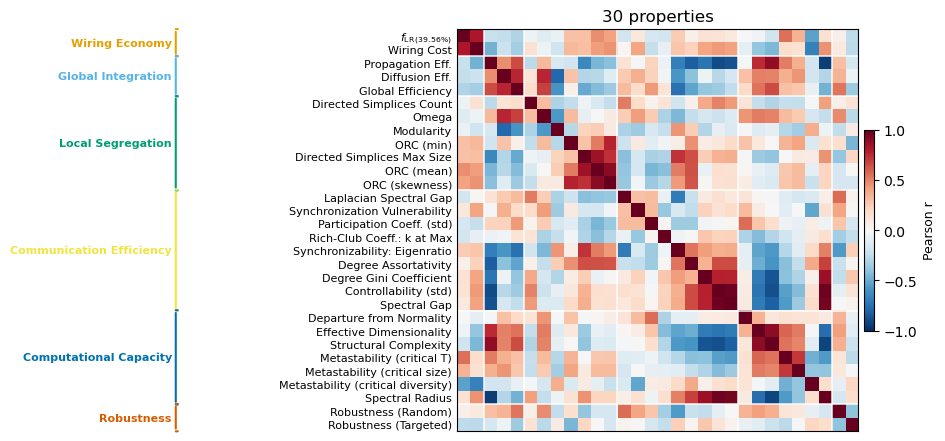

In [ ]:
# ── Build metadata from CLUSTERS ──────────────────────────────────────────────
var_to_category = {
    var: category
    for category, vars in CLUSTERS.items()
    for var in vars
}

meta = pd.DataFrame({"var": var_to_category.keys(),
                     "Category": var_to_category.values()}).set_index("var")

missing_vars = [c for c in huge_df_properties.columns if c not in meta.index]
if missing_vars:
    print("Missing variables in metadata:")
    print("\n".join(missing_vars))

# ── Sort variables by category, then column name ──────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]

def sort_key(col):
    cat = meta.loc[col, "Category"] if col in meta.index else "ZZZ"
    cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
    return (cat_idx, col)

cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)

# ── Within-category hierarchical clustering ───────────────────────────────────
corr_full = huge_df_properties[cols_in_data].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue
    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    final_order.extend([cat_cols[i] for i in leaves_list(Z)])
final_order.extend([c for c in cols_in_data if c not in final_order])

reduced_corr = corr_full.loc[final_order, final_order]
new_labels = [SELECTED_PROPERTIES_NAMES.get(c, c) for c in final_order]

# ── Plot ───────────────────────────────────────────────────────────────────────
n = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18, 12)))
gs  = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(reduced_corr.values, cmap="RdBu_r", vmin=-1, vmax=1,
               aspect="equal", interpolation="nearest")

boundaries, prev_cat = [0], meta.loc[final_order[0], "Category"]
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)
for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.set_xticks([])
ax.tick_params(axis="both", which="both", length=0)

# ── Category brackets on the left ─────────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   = 0.005
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    cat_row_spans.setdefault(cat, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cat, (r0, r1) in cat_row_spans.items():
    colour       = CATEGORY_COLOURS.get(cat, "#444444")
    weird_adapter = 0.00085
    y_top = row_to_y(r0, n) + 0.5 / n + weird_adapter
    y_bot = row_to_y(r1, n) - 0.5 / n - weird_adapter
    y_mid = (y_top + y_bot) / 2
    kw    = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                 arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))
    ax.annotate("", xy=(BRACKET_X, y_bot),            xytext=(BRACKET_X, y_top),            **kw)
    ax.annotate("", xy=(BRACKET_X, y_top),            xytext=(BRACKET_X + SERIF_W, y_top),  **kw)
    ax.annotate("", xy=(BRACKET_X, y_bot),            xytext=(BRACKET_X + SERIF_W, y_bot),  **kw)
    ax.text(LABEL_X, y_mid, cat, transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties")

plt.savefig(output_folder / f"{dataset_name}_corr_matrix_categorised.pdf", bbox_inches="tight", dpi=300)
print(output_folder / f"{dataset_name}_corr_matrix_categorised.pdf")
plt.show()


In [ ]:
# Turn a few properties around, such that every cluster in the correlation matrix correlates positively within itself (makes it easier to see the clusters visually, and also more intuitive to describe them as 'groups of properties that all capture a similar underlying feature')
# properties_to_flip = ["rich_club_coefficient_rc_k_at_max", 
#                 'directed_simplices_count',
#                 'participation_coefficient_pc_frac_connector',
#                 'community_synchronization_vulnerability_n_communities',
#                 'participation_coefficient_n_communities',
#                 'repertoire_sweep_weighted_by_distances_diversity_critical']
# for prop in properties_to_flip:
#     if prop in huge_df_properties.columns:
#         huge_df_properties[prop] = -huge_df_properties[prop]
#         print(f"Flipped '{prop}'")                    

Text(0.5, 1.0, '30 properties')

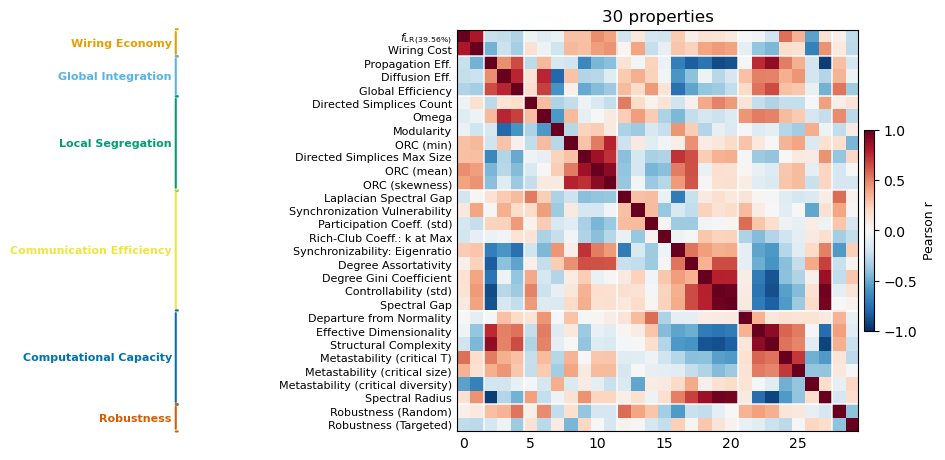

In [ ]:

# ── 2. Sort variables by category, then section ───────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]
cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)

# ── 3. Within-category hierarchical clustering ────────────────────────────────
corr_full = huge_df_properties[cols_in_data].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue
    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    Z = linkage(squareform(dist, checks=False), method="average")
    final_order.extend([cat_cols[i] for i in leaves_list(Z)])

# Append any uncategorised variables at the end
final_order.extend([c for c in cols_in_data if c not in final_order])

# ── 4. Reorder & label ────────────────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]
new_labels = [SELECTED_PROPERTIES_NAMES.get(c, c) for c in final_order]

# ── 5. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18,12)))

gs = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu_r", vmin=-1, vmax=1,
    aspect="equal", 
    interpolation="none",
)

# White dividers between categories
boundaries, prev_cat = [0], meta.loc[final_order[0], "Category"]
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)

for b in boundaries[1:-1]:
    ax.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

# Tick labels
# ax.set_xticks(np.arange(n))
# ax.set_xticklabels(new_labels, rotation=90, fontsize=8, ha="right")
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Category brackets on the left ─────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   = 0.005 
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    cat_row_spans.setdefault(cat, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cat, (r0, r1) in cat_row_spans.items():
    colour  = CATEGORY_COLOURS.get(cat, "#444444")
    weird_adapter = 0.00085
    y_top   = row_to_y(r0, n) + 0.5 / n + weird_adapter
    y_bot   = row_to_y(r1, n) - 0.5 / n - weird_adapter
    y_mid   = (y_top + y_bot) / 2
    kw      = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),       xytext=(BRACKET_X, y_top),   **kw)  # vertical bar
    ax.annotate("", xy=(BRACKET_X, y_top),        xytext=(BRACKET_X+SERIF_W, y_top), **kw)  # top serif
    ax.annotate("", xy=(BRACKET_X, y_bot),        xytext=(BRACKET_X+SERIF_W, y_bot), **kw)  # bottom serif
    ax.text(LABEL_X, y_mid, cat, transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties", # Correlation Matrix - {n} metrics (ordered by category, clustered within)",
            #  fontsize=11, 
            #  pad=8
             )

In [ ]:
for p in huge_df_properties.columns: 
    print(p)

modularity
degree_gini
degree_assortativity
omega
structural_complexity
directed_simplices_count
directed_simplices_max_size
global_efficiency
diffusion_efficiency
propagation_efficiency
wiring_cost
proportion_long_range_connections_0.3956
rich_club_coefficient_rc_k_at_max
spectral_radius
spectral_gap
synchronizability_eigenratio_eigenratio
algebraic_connectivity_laplacian_spectral_gap
departure_from_normality_schur
effective_dimensionality
repertoire_sweep_weighted_by_distances_T_critical
repertoire_sweep_weighted_by_distances_size_critical
repertoire_sweep_weighted_by_distances_diversity_critical
participation_coefficient_pc_std
ollivier_ricci_curvature_orc_mean
ollivier_ricci_curvature_orc_min
ollivier_ricci_curvature_orc_skewness
targeted_attack_robustness_rob_targeted_auc
targeted_attack_robustness_rob_random_auc
community_synchronization_vulnerability_value
nct_control_std


In [ ]:
len(huge_df_properties.columns)

30

In [ ]:

# properties_to_remove = ['community_synchronization_vulnerability_n_communities']

huge_df_properties_pos_correlations = huge_df_properties.copy() # .drop(columns=properties_to_remove) if properties_to_remove is not None else huge_df_properties.copy()


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages_consensus/lexis_data_developing_consensus_per_age_1_year_corr_matrix_clustered_automatically.pdf


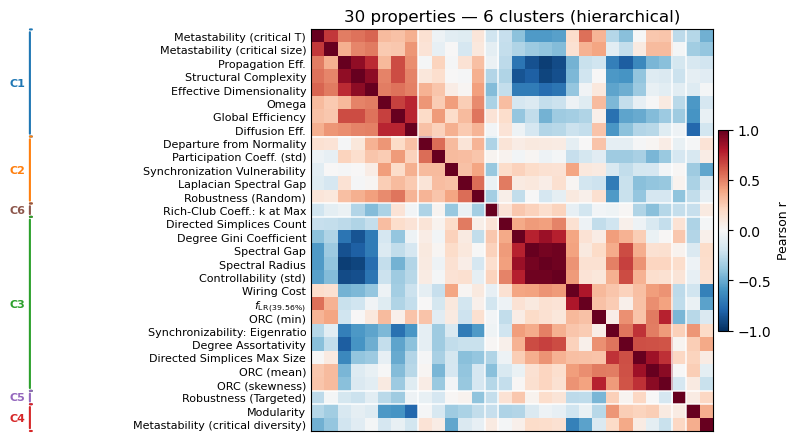


Cluster 1 (8 vars):
  Metastability (critical T), Metastability (critical size), Propagation Eff., Structural Complexity, Effective Dimensionality, Omega, Global Efficiency, Diffusion Eff.

Cluster 2 (5 vars):
  Departure from Normality, Participation Coeff. (std), Synchronization Vulnerability, Laplacian Spectral Gap, Robustness (Random)

Cluster 3 (13 vars):
  Directed Simplices Count, Degree Gini Coefficient, Spectral Gap, Spectral Radius, Controllability (std), Wiring Cost, $f_{{\rm LR\,(39.56\%)}}$, ORC (min), Synchronizability: Eigenratio, Degree Assortativity, Directed Simplices Max Size, ORC (mean), ORC (skewness)

Cluster 4 (2 vars):
  Modularity, Metastability (critical diversity)

Cluster 5 (1 vars):
  Robustness (Targeted)

Cluster 6 (1 vars):
  Rich-Club Coeff.: k at Max


{1: ['repertoire_sweep_weighted_by_distances_T_critical',
  'repertoire_sweep_weighted_by_distances_size_critical',
  'propagation_efficiency',
  'structural_complexity',
  'effective_dimensionality',
  'omega',
  'global_efficiency',
  'diffusion_efficiency'],
 2: ['departure_from_normality_schur',
  'participation_coefficient_pc_std',
  'community_synchronization_vulnerability_value',
  'algebraic_connectivity_laplacian_spectral_gap',
  'targeted_attack_robustness_rob_random_auc'],
 3: ['directed_simplices_count',
  'degree_gini',
  'spectral_gap',
  'spectral_radius',
  'nct_control_std',
  'wiring_cost',
  'proportion_long_range_connections_0.3956',
  'ollivier_ricci_curvature_orc_min',
  'synchronizability_eigenratio_eigenratio',
  'degree_assortativity',
  'directed_simplices_max_size',
  'ollivier_ricci_curvature_orc_mean',
  'ollivier_ricci_curvature_orc_skewness'],
 4: ['modularity',
  'repertoire_sweep_weighted_by_distances_diversity_critical'],
 5: ['targeted_attack_robustne

In [ ]:
# ── 1. Full-matrix hierarchical clustering ────────────────────────────────────
cols_in_data = [c for c in huge_df_properties_pos_correlations.columns if c in meta.index]
corr_full    = huge_df_properties_pos_correlations[cols_in_data].corr()

dist = np.clip(1 - corr_full.values, 0, 2)
# dist = np.clip(1 - np.abs(corr_full.values), 0, 1)  # was: 1 - corr_full.values

np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method="average")

final_order  = [cols_in_data[i] for i in leaves_list(Z)]
reduced_corr = corr_full.loc[final_order, final_order]
new_labels   = [SELECTED_PROPERTIES_NAMES.get(c, c) for c in final_order]

# ── 2. Cut the dendrogram into N clusters & assign colours ───────────────────
N_CLUSTERS = 6  # ← tune this
cluster_ids = fcluster(Z, N_CLUSTERS, criterion="maxclust")
# fcluster returns ids in original column order, remap to final_order
orig_to_cluster = dict(zip(cols_in_data, cluster_ids))

cluster_palette = plt.cm.tab10.colors
def cluster_colour(col):
    cid = orig_to_cluster.get(col, 0)
    return cluster_palette[(cid - 1) % len(cluster_palette)]

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n   = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18, 12)))
gs  = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu_r", vmin=-1, vmax=1,
    aspect="equal", interpolation="nearest",
)

# ── 4. White dividers between clusters ───────────────────────────────────────
prev_c = orig_to_cluster[final_order[0]]
for i, col in enumerate(final_order[1:], start=1):
    if orig_to_cluster[col] != prev_c:
        ax.axhline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
        ax.axvline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
    prev_c = orig_to_cluster[col]

# ── 5. Tick labels ────────────────────────────────────────────────────────────
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.set_xticks([])
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Cluster brackets on the left ──────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   =  0.005
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

# Build row spans per cluster (in display order)
cluster_row_spans = {}
for row_i, col in enumerate(final_order):
    cid = orig_to_cluster[col]
    cluster_row_spans.setdefault(cid, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cid, (r0, r1) in cluster_row_spans.items():
    colour = cluster_palette[(cid - 1) % len(cluster_palette)]
    y_top  = row_to_y(r0, n) + 0.5 / n
    y_bot  = row_to_y(r1, n) - 0.5 / n
    y_mid  = (y_top + y_bot) / 2
    kw     = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                  arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),            xytext=(BRACKET_X, y_top),            **kw)
    ax.annotate("", xy=(BRACKET_X, y_top),             xytext=(BRACKET_X + SERIF_W, y_top),  **kw)
    ax.annotate("", xy=(BRACKET_X, y_bot),             xytext=(BRACKET_X + SERIF_W, y_bot),  **kw)
    ax.text(LABEL_X, y_mid, f"C{cid}", transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties — {N_CLUSTERS} clusters (hierarchical)")

plt.savefig(output_folder / f"{dataset_name}_corr_matrix_clustered_automatically.pdf", bbox_inches="tight")
print(output_folder / f"{dataset_name}_corr_matrix_clustered_automatically.pdf")
plt.show()

# ── 7. Print cluster compositions ─────────────────────────────────────────────
categories = {}
for cid in sorted(cluster_row_spans):
    members = [SELECTED_PROPERTIES_NAMES.get(c, c) for c in final_order
               if orig_to_cluster[c] == cid]
    print(f"\nCluster {cid} ({len(members)} vars):")
    print("  " + ", ".join(members))
    
    
    categories[int(cid)] = [c for c in final_order
                       if orig_to_cluster[c] == cid]
 
categories

In [ ]:
huge_df_properties['proportion_long_range_connections_0.3956'].isna().sum()

np.int64(0)

In [ ]:
huge_df_properties.columns, len(huge_df_properties.columns) 

(Index(['modularity', 'degree_gini', 'degree_assortativity', 'omega',
        'structural_complexity', 'directed_simplices_count',
        'directed_simplices_max_size', 'global_efficiency',
        'diffusion_efficiency', 'propagation_efficiency', 'wiring_cost',
        'proportion_long_range_connections_0.3956',
        'rich_club_coefficient_rc_k_at_max', 'spectral_radius', 'spectral_gap',
        'synchronizability_eigenratio_eigenratio',
        'algebraic_connectivity_laplacian_spectral_gap',
        'departure_from_normality_schur', 'effective_dimensionality',
        'repertoire_sweep_weighted_by_distances_T_critical',
        'repertoire_sweep_weighted_by_distances_size_critical',
        'repertoire_sweep_weighted_by_distances_diversity_critical',
        'participation_coefficient_pc_std', 'ollivier_ricci_curvature_orc_mean',
        'ollivier_ricci_curvature_orc_min',
        'ollivier_ricci_curvature_orc_skewness',
        'targeted_attack_robustness_rob_targeted_auc',
   

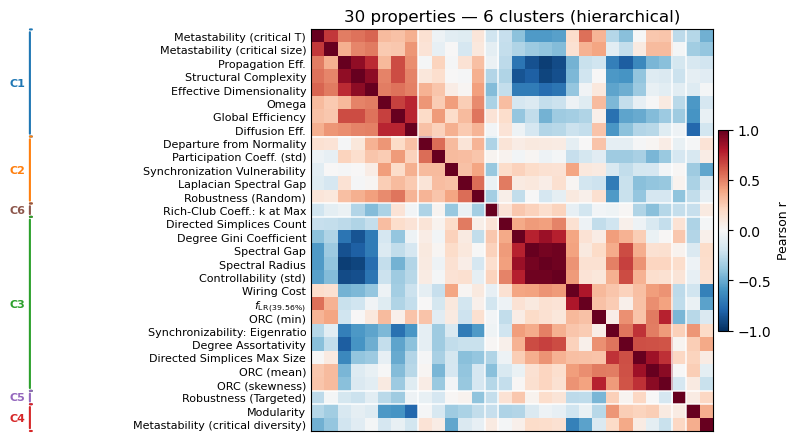


Cluster 1 (8 vars):
  Metastability (critical T), Metastability (critical size), Propagation Eff., Structural Complexity, Effective Dimensionality, Omega, Global Efficiency, Diffusion Eff.

Cluster 2 (5 vars):
  Departure from Normality, Participation Coeff. (std), Synchronization Vulnerability, Laplacian Spectral Gap, Robustness (Random)

Cluster 3 (13 vars):
  Directed Simplices Count, Degree Gini Coefficient, Spectral Gap, Spectral Radius, Controllability (std), Wiring Cost, $f_{{\rm LR\,(39.56\%)}}$, ORC (min), Synchronizability: Eigenratio, Degree Assortativity, Directed Simplices Max Size, ORC (mean), ORC (skewness)

Cluster 4 (2 vars):
  Modularity, Metastability (critical diversity)

Cluster 5 (1 vars):
  Robustness (Targeted)

Cluster 6 (1 vars):
  Rich-Club Coeff.: k at Max


In [ ]:


# ── 1. Full-matrix hierarchical clustering ────────────────────────────────────
cols_in_data = [c for c in huge_df_properties.columns if c in meta.index]
corr_full    = huge_df_properties[cols_in_data].corr()

# Fill NaNs before computing distance (NaN arises from constant or collinear columns)
corr_clean = corr_full.fillna(0)  # treat unknown correlation as uncorrelated

dist = np.clip(1 - corr_clean.values, 0, 2)
np.fill_diagonal(dist, 0)
Z = linkage(squareform(dist, checks=False), method="average")

final_order  = [cols_in_data[i] for i in leaves_list(Z)]
reduced_corr = corr_full.loc[final_order, final_order]
new_labels   = [SELECTED_PROPERTIES_NAMES.get(c, c) for c in final_order]

# ── 2. Cut the dendrogram into N clusters & assign colours ───────────────────
N_CLUSTERS = 6  # ← tune this
cluster_ids = fcluster(Z, N_CLUSTERS, criterion="maxclust")
# fcluster returns ids in original column order, remap to final_order
orig_to_cluster = dict(zip(cols_in_data, cluster_ids))

cluster_palette = plt.cm.tab10.colors
def cluster_colour(col):
    cid = orig_to_cluster.get(col, 0)
    return cluster_palette[(cid - 1) % len(cluster_palette)]

# ── 3. Plot ───────────────────────────────────────────────────────────────────
n   = len(final_order)
fig = plt.figure(figsize=viz.cm_to_inch((18, 12)))
gs  = gridspec.GridSpec(1, 1, left=0.22, right=0.97, top=0.97, bottom=0.12)
ax  = fig.add_subplot(gs[0])

im = ax.imshow(
    reduced_corr.values,
    cmap="RdBu_r", vmin=-1, vmax=1,
    aspect="equal", interpolation="nearest",
)

# ── 4. White dividers between clusters ───────────────────────────────────────
prev_c = orig_to_cluster[final_order[0]]
for i, col in enumerate(final_order[1:], start=1):
    if orig_to_cluster[col] != prev_c:
        ax.axhline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
        ax.axvline(i - 0.5, color="white", linewidth=1.2, alpha=0.85)
    prev_c = orig_to_cluster[col]

# ── 5. Tick labels ────────────────────────────────────────────────────────────
ax.set_yticks(np.arange(n))
ax.set_yticklabels(new_labels, fontsize=8)
ax.set_xticks([])
ax.tick_params(axis="both", which="both", length=0)

# ── 6. Cluster brackets on the left ──────────────────────────────────────────
moving_stuff = -0.5
BRACKET_X = -0.20 + moving_stuff
SERIF_W   =  0.005
LABEL_X   = -0.21 + moving_stuff
trans     = ax.transAxes

# Build row spans per cluster (in display order)
cluster_row_spans = {}
for row_i, col in enumerate(final_order):
    cid = orig_to_cluster[col]
    cluster_row_spans.setdefault(cid, [row_i, row_i])[1] = row_i

def row_to_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

for cid, (r0, r1) in cluster_row_spans.items():
    colour = cluster_palette[(cid - 1) % len(cluster_palette)]
    y_top  = row_to_y(r0, n) + 0.5 / n
    y_bot  = row_to_y(r1, n) - 0.5 / n
    y_mid  = (y_top + y_bot) / 2
    kw     = dict(xycoords=trans, textcoords=trans, annotation_clip=False,
                  arrowprops=dict(arrowstyle="-", color=colour, lw=1.5))

    ax.annotate("", xy=(BRACKET_X, y_bot),            xytext=(BRACKET_X, y_top),            **kw)
    ax.annotate("", xy=(BRACKET_X, y_top),             xytext=(BRACKET_X + SERIF_W, y_top),  **kw)
    ax.annotate("", xy=(BRACKET_X, y_bot),             xytext=(BRACKET_X + SERIF_W, y_bot),  **kw)
    ax.text(LABEL_X, y_mid, f"C{cid}", transform=trans,
            ha="right", va="center", fontsize=8, fontweight="bold",
            color=colour, clip_on=False)

cbar = fig.colorbar(im, ax=ax, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)
ax.set_title(f"{n} properties — {N_CLUSTERS} clusters (hierarchical)")

plt.savefig(output_folder / f"{dataset_name}_corr_matrix_clustered.pdf", bbox_inches="tight")
plt.show()

# ── 7. Print cluster compositions ─────────────────────────────────────────────
for cid in sorted(cluster_row_spans):
    members = [SELECTED_PROPERTIES_NAMES.get(c, c) for c in final_order
               if orig_to_cluster[c] == cid]
    print(f"\nCluster {cid} ({len(members)} vars):")
    print("  " + ", ".join(members))

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_3722/3639930887.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


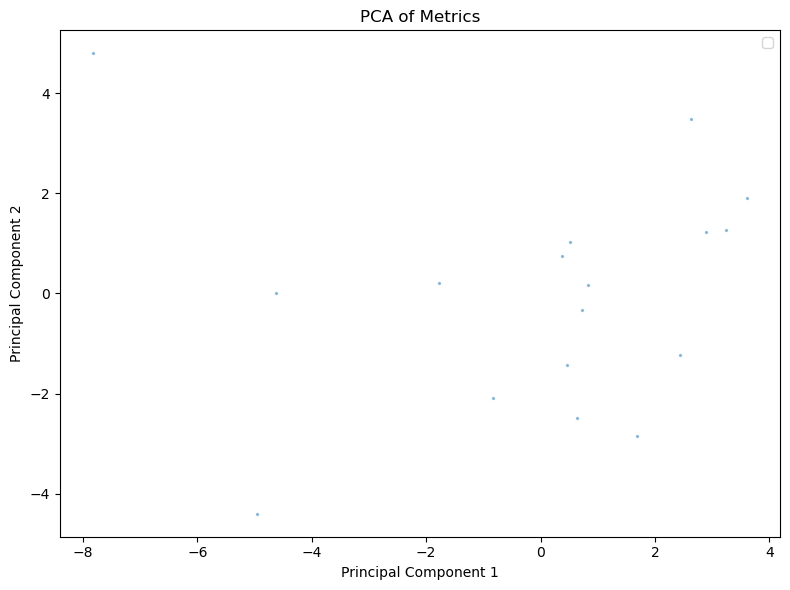

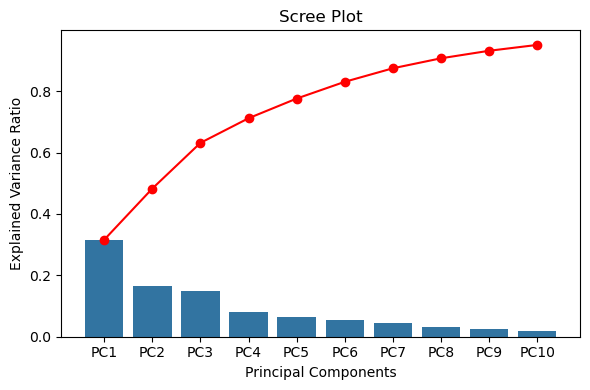

In [ ]:

# Drop the columns that have inf or -inf values (if any). Print the dropped columns
# dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
# huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
# huge_df_properties.dropna(axis=1, inplace=True)
# print(f"Dropped columns: {dropped_cols}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(x=pca_result[:,0], 
            y=pca_result[:,1], 
            s=2, 
            alpha=0.4, 
        #     c=huge_df['color_dataset'], 
            # label=huge_df['dataset']
        )
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
        label="Cumulative")
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()

In [ ]:
# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort((loadings[:, 0]))[::-1]
# sorted_indices = np.argsort(np.abs(loadings[:, 0]) + np.abs(loadings[:, 1]))[::-1]
abs_ordered_loadings = np.abs(loadings[sorted_indices, 0])
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages_consensus/lexis_data_developing_consensus_per_age_1_year_pca_loadings_coloured_by_category.pdf


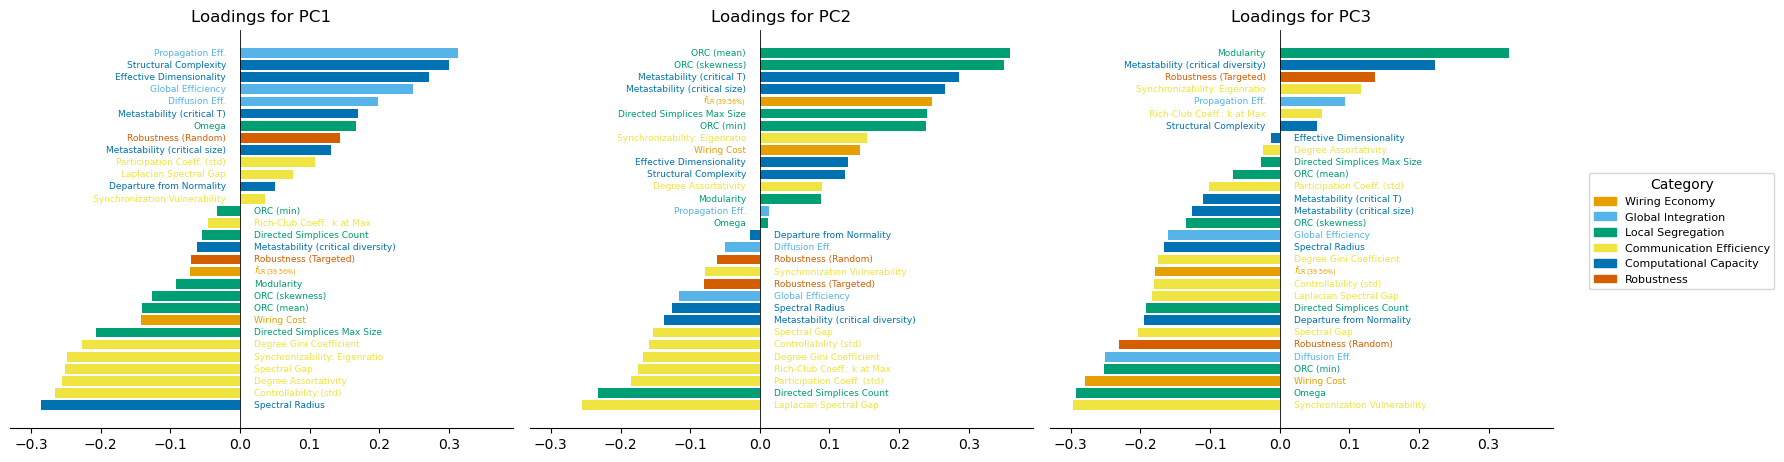

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=3,
                        figsize=viz.cm_to_inch((40, 12)),
                        sharex=True)

for i in range(3):
    ordered_pc_i    = np.argsort(loadings[:, i])
    loadings_sorted = loadings[ordered_pc_i]
    names_sorted    = metric_names[ordered_pc_i]
    names_long      = [SELECTED_PROPERTIES_NAMES[m] for m in names_sorted]

    bar_colours = []
    for m in names_sorted:
        cat = meta.loc[m, "Category"] if m in meta.index else None
        bar_colours.append(CATEGORY_COLOURS.get(cat, "#AAAAAA"))

    axs[i].barh(range(num_metrics), loadings_sorted[:, i], color=bar_colours)
    axs[i].axvline(0, color="black", linewidth=0.6)
    axs[i].set_title(f"Loadings for PC{i+1}")

    # Remove default y tick labels
    axs[i].set_yticks([])

    PAD = 0.02  # small gap from the zero line in data units
    for j, (val, name, colour) in enumerate(zip(loadings_sorted[:, i], names_long, bar_colours)):
        if val >= 0:
            # Bar goes right → label on the left of zero
            axs[i].text(-PAD, j, name,
                        ha="right", va="center", fontsize=6.5,
                        color=colour, # fontweight="bold"
                        )
        else:
            # Bar goes left → label on the right of zero
            axs[i].text(PAD, j, name,
                        ha="left", va="center", fontsize=6.5,
                        color=colour,
                        # fontweight="bold"
                        )
            
    # Remove spines and ticks for a cleaner look
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['left'].set_visible(False)

# Legend
handles = [mpatches.Patch(color=c, label=cat)
           for cat, c in CATEGORY_COLOURS.items()
           if cat in meta["Category"].values]
fig.legend(handles=handles, title="Category",
           bbox_to_anchor=(1.01, 0.5), loc="center left", fontsize=8)

plt.tight_layout()
plt.savefig(output_folder / f"{dataset_name}_pca_loadings_coloured_by_category.pdf", bbox_inches="tight")
print(output_folder / f"{dataset_name}_pca_loadings_coloured_by_category.pdf")
plt.show()

In [ ]:
# ── Helper: spider plot ───────────────────────────────────────────────────────
def make_spider(ax, values, label, color, axis_labels, title=None):
    """Draw a single radar/spider plot on a polar axis."""
    n = len(axis_labels)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]
    vals = list(values) + [values[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=0.15)
    ax.set_thetagrids(np.degrees(angles[:-1]), axis_labels, fontsize=7)
    ax.tick_params(pad=6)
    if title:
        ax.set_title(title, fontsize=9, pad=14)


rep_keys   = list(selected_properties.values())
rep_labels = list(selected_properties.keys()) 
rep_idx    = [huge_df_properties.columns.get_loc(k) for k in rep_keys]

# ── Angles for spider (shared across all spider plots) ───────────────────────
n_axes   = len(rep_labels)
angles   = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles  += angles[:1]


# ── Corner point definitions ──────────────────────────────────────────────────
CORNER_COLORS = {
    "top_left":     "steelblue",
    "bottom_left":  "orange",
    "bottom_right": "forestgreen",
}

def find_corners(pca_result_2d):
    """Return a dict of corner name → row index within pca_result_2d."""
    return {
        "top_left":     int(np.argmax( pca_result_2d[:, 1])),
        "bottom_left":  int(np.argmax(-pca_result_2d[:, 0] - pca_result_2d[:, 1])),
        "bottom_right": int(np.argmax( pca_result_2d[:, 0] - pca_result_2d[:, 1])),
    }

KeyError: 'ipc_ipc_deg1_mean'

In [ ]:
# # ── Corners in the full selected-properties PCA space ────────────────────────
corners_full = find_corners(pca_result)

# print("Corner points (full dataset):")
# for name, idx in corners_full.items():
#     ds = huge_df["dataset"].iloc[idx]
#     print(f"  {name}: idx={idx}, PC1={pca_result[idx,0]:.2f}, PC2={pca_result[idx,1]:.2f}, dataset={ds}")

# # ── Visualise ─────────────────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(8, 6))
# for ds in huge_df["dataset"].unique():
#     mask = (huge_df["dataset"] == ds).values
#     ax.scatter(pca_result[mask, 0], pca_result[mask, 1],
#                c=COLOR_SCHEME[ds], label=LABEL_MAP[ds], # .get(ds, ds),
#                alpha=0.4, s=8, edgecolors="none")
# for name, idx in corners_full.items():
#     ax.scatter(pca_result[idx, 0], pca_result[idx, 1],
#                s=300, zorder=5, edgecolors="black", linewidths=2,
#                color=CORNER_COLORS[name])
#     ax.annotate(name, (pca_result[idx, 0], pca_result[idx, 1]),
#                 textcoords="offset points", xytext=(8, 8), fontsize=9)
# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.set_title("PCA — Corner Points (Full Dataset)")
# ax.legend(markerscale=2, fontsize=7)
# plt.tight_layout()
# plt.show()

In [ ]:
# # ── Spider plot for the top-6 features by PC1+PC2 loading magnitude ──────────
# top6_idx = np.argsort(np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2))[::-1][:6]
# top6_names  = metric_names[top6_idx]
# top6_labels = [n.replace("_", "\n") for n in top6_names]

# fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
# for name, idx in corners_full.items():
#     vals = list(scaled_data[idx, top6_idx]) + [scaled_data[idx, top6_idx[0]]]
#     a    = np.linspace(0, 2*np.pi, 6, endpoint=False).tolist() + [0]
#     ax.plot(a, vals, color=CORNER_COLORS[name], linewidth=2, label=name)
#     ax.fill(a, vals, color=CORNER_COLORS[name], alpha=0.15)
# ax.set_thetagrids(np.degrees(np.linspace(0, 2*np.pi, 6, endpoint=False)), top6_labels, fontsize=8)
# ax.set_title("Top-6 Features at PCA Extremes (z-scored)", pad=20)
# ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
# plt.tight_layout()
# plt.show()

# # ── Spider plot using predefined goal representatives ─────────────────────────
# fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
# for name, idx in corners_full.items():
#     vals = list(scaled_data[idx, rep_idx]) + [scaled_data[idx, rep_idx[0]]]
#     ax.plot(angles, vals, color=CORNER_COLORS[name], linewidth=2, label=name)
#     ax.fill(angles, vals, color=CORNER_COLORS[name], alpha=0.15)
# ax.set_thetagrids(np.degrees(angles[:-1]), rep_labels, fontsize=8)
# ax.set_title("Network Properties at PCA Extremes (z-scored)\n— Full Dataset", pad=20)
# ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
# plt.tight_layout()
# plt.show()

In [ ]:
# def draw_axis_group_arcs(ax, feature_labels, angles, arc_radius, groups):
#     """
#     Draw a bold arc just outside the plot connecting paired spokes.
#     arc_radius: draw the arc at this r value (slightly beyond local_max).
#     """
#     theta_dense = np.linspace(0, 2 * np.pi, 1000)

#     for label_a, label_b, color in groups:
#         if label_a not in feature_labels or label_b not in feature_labels:
#             continue
#         i_a = feature_labels.index(label_a)
#         i_b = feature_labels.index(label_b)

#         angle_a = angles[i_a]
#         angle_b = angles[i_b]

#         # Always sweep the short way between the two spokes
#         if angle_b < angle_a:
#             angle_a, angle_b = angle_b, angle_a

#         # Choose the shorter arc
#         if angle_b - angle_a > np.pi:
#             arc_angles = np.linspace(angle_b, angle_a + 2 * np.pi, 80)
#         else:
#             arc_angles = np.linspace(angle_a, angle_b, 80)

#         arc_r = np.full_like(arc_angles, arc_radius)

#         ax.plot(arc_angles, arc_r,
#                 color=color, linewidth=3.5, solid_capstyle="round",
#                 zorder=0, alpha=0.85)

#         # Small dots at each endpoint to cap the arc neatly
#         ax.scatter([arc_angles[0], arc_angles[-1]],
#                    [arc_radius, arc_radius],
#                    color=color, s=18, zorder=7, alpha=0.85)


# Ages 

In [ ]:
for dataset_name, d in dict_with_all_datasets.items():
    

    # if "lexis_data_young" in dataset_name:
    if "lexis_data_" in dataset_name:
    
            print(dataset_name)
            ages = np.load(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/{dataset_name}/04_further_info/00_ages.npy")
            # Turn dict_with_all_datasets["lexis_data_aging"].index into a mask
            
            mask = np.zeros_like(ages)
            mask[dict_with_all_datasets[dataset_name].index] = 1
            mask = mask.astype(bool)
            
            # add an age column by index to the main dataframe
            dict_with_all_datasets[dataset_name]["age"] = ages[mask]
        

lexis_data_developing_consensus_per_age_1_year


In [ ]:
huge_df = pd.DataFrame()

# combine all the metrics into one dataframe for this experiment
for dataset_name in ordered_dataset_names: 
    df = dict_with_all_datasets[dataset_name]
    # Add a column to identify the dataset
    df["dataset"] = dataset_name
    
    print(dataset_name, len(df))
    # Remove this, as eta, gamma, etc are not defined here? 
    if dataset_name == "kaysons_generated_networks_topology" or dataset_name == "hcp_schaefer_100_dataset": 
        print(" ---> skipped")
        continue
    huge_df = pd.concat([huge_df, df], ignore_index=True)
    

lexis_data_developing_consensus_per_age_1_year 17


In [ ]:


# Drop the columns that have inf or -inf values (if any). Print the dropped columns
dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_properties.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(scaled_data)

# plt.figure(figsize=(8,6))
# plt.scatter(x=pca_result[:,0], 
#             y=pca_result[:,1], 
#             s=4,
#             alpha=0.4, 
#             c=huge_df["age"],
#             # c=huge_df['color_dataset'], 
#             # label=huge_df['dataset']
#         )
# plt.title("PCA of Metrics")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend()
# plt.tight_layout()
# plt.colorbar(label="Age") # if using age as color
# plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
# plt.figure(figsize=(6,4))
# sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
# plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
#         label="Cumulative")
# plt.title("Scree Plot")
# plt.ylabel("Explained Variance Ratio")
# plt.xlabel("Principal Components")
# plt.tight_layout()
# plt.show()

Dropped columns: []


In [ ]:
len(huge_df_properties)

17

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages_consensus/lexis_data_developing_consensus_per_age_1_year_pca_age_scatter_individuals.pdf


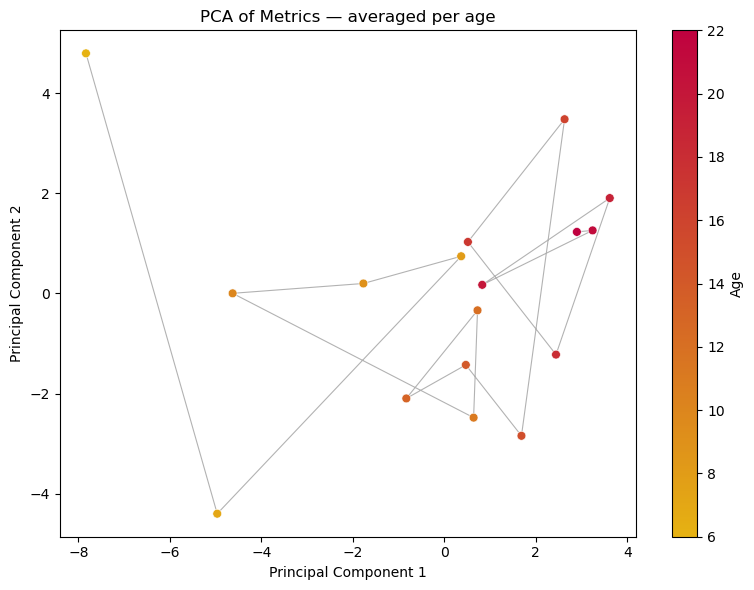

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages_consensus/lexis_data_developing_consensus_per_age_1_year_pca_scree_plot.pdf


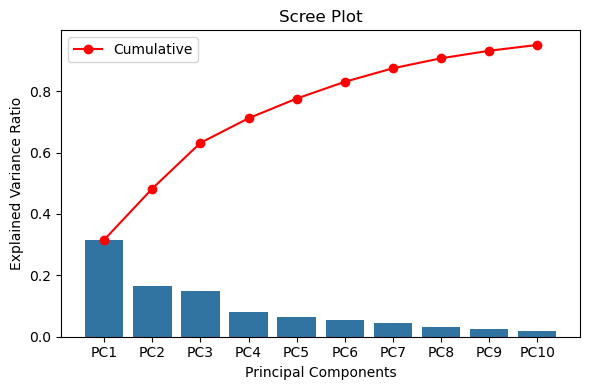

In [ ]:

# # ── 1. Clean ──────────────────────────────────────────────────────────────────
# dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
# huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
# huge_df_properties.dropna(axis=1, inplace=True)
# print(f"Dropped columns: {dropped_cols}")

# ── 2. Scale & PCA on the full data ───────────────────────────────────────────
scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=10)
pca_result = pca.fit_transform(scaled_data)

# ── 3. Average PC scores per age ──────────────────────────────────────────────
pca_df = pd.DataFrame(pca_result[:, :2], columns=["PC1", "PC2"])
pca_df["age"] = huge_df["age"].values

age_means = pca_df.groupby("age")[["PC1", "PC2"]].mean().reset_index().sort_values("age")

# ── 4. PCA scatter: averaged dots coloured by age, connected by line ──────────
fig, ax = plt.subplots(figsize=(8, 6))

norm = plt.Normalize(age_means["age"].min(), age_means["age"].max())
# cmap = plt.cm.terrain # viridis


cmap = LinearSegmentedColormap.from_list("custom", ["#E6B212", "#BF013F"])



# Line through the age-averaged points (sorted by age)
ax.plot(age_means["PC1"], age_means["PC2"],
        color="grey", linewidth=0.8, alpha=0.6, zorder=1)

# All individual ones
sc = ax.scatter(pca_df["PC1"], 
                pca_df["PC2"],
                c=pca_df["age"], cmap=cmap, norm=norm,
                s=5, 
                zorder=2, edgecolors="white", 
                linewidths=0.4)

# One dot per age, coloured by age
sc = ax.scatter(age_means["PC1"], age_means["PC2"],
                c=age_means["age"], cmap=cmap, norm=norm,
                s=40, zorder=2, edgecolors="white", linewidths=0.4)

plt.colorbar(sc, ax=ax, label="Age")
ax.set_title("PCA of Metrics — averaged per age")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.tight_layout()

plt.savefig(output_folder / f"{dataset_name}_pca_age_scatter_individuals.pdf", bbox_inches="tight")
print(output_folder / f"{dataset_name}_pca_age_scatter_individuals.pdf")
plt.show()

# ── 5. Scree plot ─────────────────────────────────────────────────────────────
explained_variance = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))],
            y=explained_variance, ax=ax)
ax.plot(range(len(explained_variance)), np.cumsum(explained_variance),
        marker="o", color="red", label="Cumulative")
ax.set_title("Scree Plot")
ax.set_ylabel("Explained Variance Ratio")
ax.set_xlabel("Principal Components")
ax.legend()
plt.tight_layout()

plt.savefig(output_folder / f"{dataset_name}_pca_scree_plot.pdf", dpi=150, bbox_inches="tight")
print(output_folder / f"{dataset_name}_pca_scree_plot.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages_consensus/lexis_data_developing_consensus_per_age_1_year_pca_age.pdf


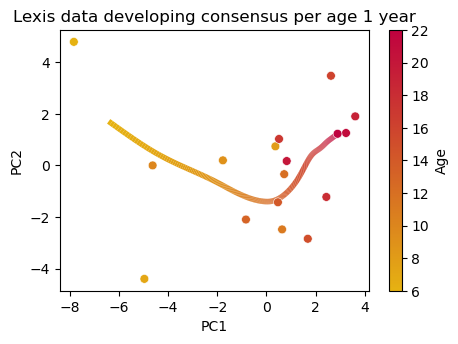

In [ ]:
age_vals = age_means["age"].values
t = np.linspace(age_vals.min(), age_vals.max(), 300)

smooth_pc1 = make_smoothing_spline(age_vals, age_means["PC1"].values, lam=5)(t)
smooth_pc2 = make_smoothing_spline(age_vals, age_means["PC2"].values, lam=5)(t)

norm = plt.Normalize(age_vals.min(), age_vals.max())
# norm=plt.Normalize(0, 100)
# cmap = plt.cm.terrain

# ── Loadings ──────────────────────────────────────────────────────────────────
scale    = np.sqrt(pca.explained_variance_[:2])
loadings = pd.DataFrame(
    (pca.components_[:2] * scale[:, None]).T,
    index=huge_df_properties.columns,
    columns=["PC1", "PC2"]
)
n_largest = 2
top_pc1   = loadings["PC1"].abs().nlargest(n_largest).index.tolist()
top_pc2   = loadings["PC2"].abs().nlargest(n_largest).index.tolist()
top_vars  = list(dict.fromkeys(top_pc1 + top_pc2))

# ════════════════════════════════════════════════════════════════════════════
# PLOT 1 — age trajectory
# ════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=viz.cm_to_inch((12, 9)))

points   = np.array([smooth_pc1, smooth_pc2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap=cmap, 
                    norm=norm, 
                    linewidth=4, # 2, # 1.5, 
                    alpha=1, # 0.8, 
                    zorder=2
                    )
lc.set_array(t)
ax.add_collection(lc)

sc = ax.scatter(age_means["PC1"], age_means["PC2"],
                c=age_means["age"], cmap=cmap, norm=norm,
                s=40, 
                zorder=3, 
                edgecolors="white", linewidths=0.4)

# lines_ax = ax.plot(age_means["PC1"], 
#              age_means["PC2"], # age_means is already ordered. 
#                 # c=age_means["age"], 
#                 # cmap=cmap, 
#                 # norm=norm,
#                 zorder=1, 
#                 linewidth=0.2,
#                 alpha=0.6,
#                 # edgecolors="white", 
#                 # linewidths=0.2
#                 )
# print(age_means["age"])
ax.autoscale()
fig1.colorbar(sc, ax=ax, label="Age", 
            #   norm=plt.Normalize(0, 100)
              )
ax.set_title(f"{dataset_name.replace('_', ' ').capitalize()}") #  Averaged per age (after PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

fig1.tight_layout()
# fig1.savefig(output_folder / f"{dataset_name}_pca_age.pdf") # , dpi=300)
# print(output_folder / f"{dataset_name}_pca_age.pdf")
plt.show()


In [ ]:
age_vals = age_means["age"].values
t = np.linspace(age_vals.min(), age_vals.max(), 300)

smooth_pc1 = make_smoothing_spline(age_vals, age_means["PC1"].values, lam=5)(t)
smooth_pc2 = make_smoothing_spline(age_vals, age_means["PC2"].values, lam=5)(t)

norm = plt.Normalize(age_vals.min(), age_vals.max())
# norm=plt.Normalize(0, 100)
# cmap = plt.cm.terrain

# ── Loadings ──────────────────────────────────────────────────────────────────
scale    = np.sqrt(pca.explained_variance_[:2])
loadings = pd.DataFrame(
    (pca.components_[:2] * scale[:, None]).T,
    index=huge_df_properties.columns,
    columns=["PC1", "PC2"]
)
n_largest = 2
top_pc1   = loadings["PC1"].abs().nlargest(n_largest).index.tolist()
top_pc2   = loadings["PC2"].abs().nlargest(n_largest).index.tolist()
top_vars  = list(dict.fromkeys(top_pc1 + top_pc2))

# ════════════════════════════════════════════════════════════════════════════
# PLOT 1 — age trajectory
# ════════════════════════════════════════════════════════════════════════════
fig1, ax = plt.subplots(figsize=viz.cm_to_inch((12, 9)))

points   = np.array([smooth_pc1, smooth_pc2]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap=cmap, 
                    norm=norm, 
                    linewidth=4, # 2, # 1.5, 
                    alpha=1, # 0.8, 
                    zorder=2
                    )
lc.set_array(t)
ax.add_collection(lc)

sc = ax.scatter(age_means["PC1"], age_means["PC2"],
                c=age_means["age"], cmap=cmap, norm=norm,
                s=40, 
                zorder=3, 
                edgecolors="white", linewidths=0.4)

# Label the points of minimum and maximum age 
min_age_idx = age_means["age"].idxmin()
max_age_idx = age_means["age"].idxmax()
ax.scatter(age_means.loc[min_age_idx, "PC1"], age_means.loc[min_age_idx, "PC2"],
           s=100, zorder=4, edgecolors="black", linewidths=2,
           color="blue", label=f"Min Age: {age_means.loc[min_age_idx, 'age']}")
ax.scatter(age_means.loc[max_age_idx, "PC1"], age_means.loc[max_age_idx, "PC2"],
           s=100, zorder=4, edgecolors="black", linewidths=2,
           color="red", label=f"Max Age: {age_means.loc[max_age_idx, 'age']}")
# ax.legend(loc="upper right", fontsize=8)

# lines_ax = ax.plot(age_means["PC1"], 
#              age_means["PC2"], # age_means is already ordered. 
#                 # c=age_means["age"], 
#                 # cmap=cmap, 
#                 # norm=norm,
#                 zorder=1, 
#                 linewidth=0.2,
#                 alpha=0.6,
#                 # edgecolors="white", 
#                 # linewidths=0.2
#                 )
# print(age_means["age"])
ax.autoscale()
fig1.colorbar(sc, ax=ax, label="Age", 
            #   norm=plt.Normalize(0, 100)
              )
# ax.set_title(f"{dataset_name.replace('_', ' ').capitalize()}") #  Averaged per age (after PCA)")
ax.set_title(f"Human development ({age_means['age'].min()}-{age_means['age'].max()} years)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

fig1.tight_layout()
fig1.savefig(output_folder / f"{dataset_name}_pca_age.pdf") # , dpi=300)
print(output_folder / f"{dataset_name}_pca_age.pdf")
plt.show()


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages_consensus/lexis_data_developing_consensus_per_age_1_year_pca_age_3d.pdf


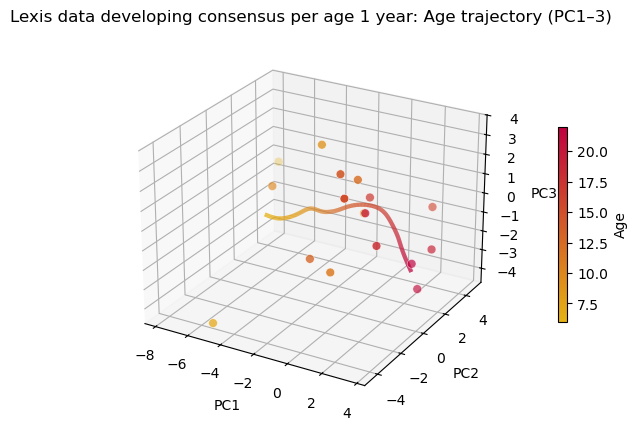

In [ ]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from scipy.interpolate import make_smoothing_spline

# ── Extend to PC3 ─────────────────────────────────────────────────────────────
pca_df["PC3"] = pca_result[:, 2]
age_means = pca_df.groupby("age")[["PC1", "PC2", "PC3"]].mean().reset_index().sort_values("age")

age_vals   = age_means["age"].values
t          = np.linspace(age_vals.min(), age_vals.max(), 300)
# norm       = plt.Normalize(age_vals.min(), age_vals.max())
# norm = plt.Normalize(0, 100)
# cmap       = plt.cm.terrain


smooth_pc1 = make_smoothing_spline(age_vals, age_means["PC1"].values, lam=5)(t)
smooth_pc2 = make_smoothing_spline(age_vals, age_means["PC2"].values, lam=5)(t)
smooth_pc3 = make_smoothing_spline(age_vals, age_means["PC3"].values, lam=5)(t)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig1 = plt.figure(figsize=viz.cm_to_inch((14, 11)))
ax   = fig1.add_subplot(111, projection="3d")

# Smooth coloured tube via Line3DCollection
points   = np.array([smooth_pc1, smooth_pc2, smooth_pc3]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = Line3DCollection(segments, cmap=cmap, norm=norm, linewidth=3, alpha=0.9, zorder=2)
lc.set_array(t)
ax.add_collection3d(lc)

# Raw averaged dots
sc = ax.scatter(age_means["PC1"], age_means["PC2"], age_means["PC3"],
                c=age_means["age"], cmap=cmap, norm=norm,
                s=40, zorder=3, edgecolors="white", linewidths=0.4,
                depthshade=True)

# # Faint raw polyline
# ax.plot(age_means["PC1"], age_means["PC2"], age_means["PC3"],
#         color="grey", linewidth=0.4, alpha=0.5, zorder=1)

# Shadow projections on each wall (optional but nice in 3D)
z_floor = age_means["PC3"].min() - 0.3
x_wall  = ax.get_xlim()[0] if ax.get_xlim()[0] != ax.get_xlim()[1] else age_means["PC1"].min() - 0.5
# ax.plot(age_means["PC1"], age_means["PC2"],
#         zs=z_floor, zdir="z",
#         color="grey", linewidth=0.5, alpha=0.25)
# ax.plot(age_means["PC1"], age_means["PC3"],
#         zs=age_means["PC2"].max() + 0.3, zdir="y",
#         color="grey", linewidth=0.5, alpha=0.25)

fig1.colorbar(sc, ax=ax, label="Age", shrink=0.5, pad=0.1)
ax.set_xlabel("PC1", labelpad=6)
ax.set_ylabel("PC2", labelpad=6)
ax.set_zlabel("PC3", labelpad=6)
ax.set_title(f"{dataset_name.replace('_', ' ').capitalize()}: Age trajectory (PC1–3)")

# Nice default viewing angle — adjust to taste
ax.view_init(elev=25, azim=-60)

fig1.tight_layout()
fig1.savefig(output_folder / f"{dataset_name}_pca_age_3d.pdf") # , dpi=300)
print(output_folder / f"{dataset_name}_pca_age_3d.pdf")
plt.show()

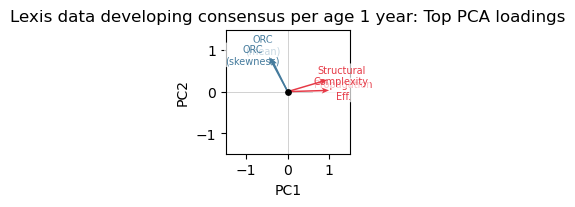

In [ ]:

# ════════════════════════════════════════════════════════════════════════════
# PLOT 2 — loading vectors
# ════════════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=viz.cm_to_inch((6,6)))

ax2.axhline(0, color="grey", lw=0.5, alpha=0.5)
ax2.axvline(0, color="grey", lw=0.5, alpha=0.5)
ax2.scatter([0], [0], color="black", s=15, zorder=6)

label_positions = []  # track placed labels to nudge overlaps

from adjustText import adjust_text

texts = []
for var in top_vars:
    vx     = loadings.loc[var, "PC1"]
    vy     = loadings.loc[var, "PC2"]
    colour = "#E63946" if var in top_pc1 else "#457B9D"
    if var in top_pc1 and var in top_pc2:
        colour = "#9B2226"

    ax2.quiver(
        0, 0, vx, vy,
        angles="xy", scale_units="xy", scale=1,
        color=colour, width=0.012,
        headwidth=4, headlength=5, headaxislength=4,
        zorder=5,
    )
    texts.append((var, vx, vy, colour))

# ── Fan apart labels that are too close in angle ──────────────────────────────
MIN_LABEL_DIST = 0.25  # minimum distance between label positions
LABEL_RADIUS   = 1.35  # how far beyond arrow tip

label_positions = []
for var, vx, vy, colour in texts:
    norm_r = np.sqrt(vx**2 + vy**2)
    lx = vx / norm_r * norm_r * LABEL_RADIUS
    ly = vy / norm_r * norm_r * LABEL_RADIUS

    # Fan away from already-placed labels along the perpendicular
    for attempt in range(20):
        too_close = [(px, py) for px, py in label_positions
                     if np.sqrt((lx-px)**2 + (ly-py)**2) < MIN_LABEL_DIST]
        if not too_close:
            break
        # Rotate label position slightly around origin
        angle = np.arctan2(ly, lx) + 0.15
        r     = np.sqrt(lx**2 + ly**2)
        lx, ly = r * np.cos(angle), r * np.sin(angle)

    label_positions.append((lx, ly))
    label = SELECTED_PROPERTIES_NAMES.get(var, var).replace(" ", "\n")
    ax2.text(lx, ly, label,
             fontsize=7, ha="center", va="center",
             color=colour, #  fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))


# Axis limits: symmetric, tight around actual vectors + label room
all_vals = loadings.loc[top_vars, ["PC1", "PC2"]].abs().values.max() * 1.5
ax2.set_xlim(-all_vals, all_vals)
ax2.set_ylim(-all_vals, all_vals)
ax2.set_aspect("equal")
ax2.set_xlabel("PC1") # , fontsize=9)
ax2.set_ylabel("PC2") # , fontsize=9)
ax2.set_title(f"{dataset_name.replace('_', ' ').capitalize()}: Top PCA loadings") # , fontsize=9)
ax2.tick_params() # labelsize=7)


fig2.tight_layout()
# fig2.savefig(output_folder / f"{dataset_name}_pca_loadings.pdf", dpi=300)
# print(output_folder / f"{dataset_name}_pca_loadings.pdf")
plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/01_lexi_ages_consensus/lexis_data_developing_consensus_per_age_1_year_pca_loadings.pdf


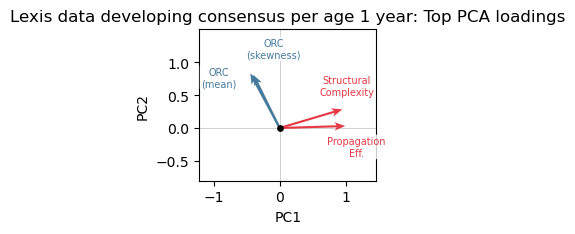

In [ ]:
# ── Fan labels by enforcing minimum angular separation ────────────────────────
LABEL_RADIUS  = 1.2   # in data units, beyond arrow tip
MIN_ANG_GAP   = 0.8 # radians (~20°) minimum between labels

# Collect arrows + initial angles
arrow_info = []
for var in top_vars:
    vx = loadings.loc[var, "PC1"]
    vy = loadings.loc[var, "PC2"]
    colour = "#E63946" if var in top_pc1 else "#457B9D"
    if var in top_pc1 and var in top_pc2:
        colour = "#9B2226"
    angle = np.arctan2(vy, vx)
    r     = np.sqrt(vx**2 + vy**2)
    arrow_info.append(dict(var=var, vx=vx, vy=vy, colour=colour, angle=angle, r=r))

# Sort by angle so we can spread neighbours apart
arrow_info.sort(key=lambda d: d["angle"])

# Push angles apart until all gaps >= MIN_ANG_GAP (a few passes suffice)
label_angles = [d["angle"] for d in arrow_info]
for _ in range(50):
    changed = False
    for i in range(len(label_angles)):
        j = (i + 1) % len(label_angles)
        gap = label_angles[j] - label_angles[i]
        if i == len(label_angles) - 1:        # wrap-around pair
            gap += 2 * np.pi
        if gap < MIN_ANG_GAP:
            push = (MIN_ANG_GAP - gap) / 2
            label_angles[i] -= push
            label_angles[j] += push
            changed = True
    if not changed:
        break

# ── Draw ──────────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=viz.cm_to_inch((7, 7)))
ax2.axhline(0, color="grey", lw=0.5, alpha=0.5)
ax2.axvline(0, color="grey", lw=0.5, alpha=0.5)
ax2.scatter([0], [0], color="black", s=15, zorder=6)

label_coords = []
for d, langle in zip(arrow_info, label_angles):
    ax2.quiver(0, 0, d["vx"], d["vy"],
               angles="xy", scale_units="xy", scale=1,
               color=d["colour"], width=0.012,
               headwidth=4, headlength=5, headaxislength=4, zorder=5)

    # Label position: at LABEL_RADIUS along the (possibly fanned) angle
    lx = LABEL_RADIUS * np.cos(langle)
    ly = LABEL_RADIUS * np.sin(langle)
    label_coords.append((lx, ly))

    # Thin connector from arrow tip to label if angle was moved
    # tip_x, tip_y = d["vx"] * 1.05, d["vy"] * 1.05
    # if abs(langle - d["angle"]) > 0.05:
    #     ax2.plot([tip_x, lx], [tip_y, ly],
    #              color=d["colour"], lw=0.5, alpha=0.6, zorder=4)

    label = SELECTED_PROPERTIES_NAMES.get(d["var"], d["var"]).replace(" ", "\n")
    ax2.text(lx, ly, label,
             fontsize=7, ha="center", va="center",
             color=d["colour"],
             bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

# Axis limits: fit both arrows and labels
all_lx = [lx for lx, ly in label_coords]
all_ly = [ly for lx, ly in label_coords]
pad = 0.3
ax2.set_xlim(min(min(all_lx), -0.5) - pad, max(max(all_lx), 0.5) + pad)
ax2.set_ylim(min(min(all_ly), -0.5) - pad, max(max(all_ly), 0.5) + pad)
ax2.set_aspect("equal")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title(f"{dataset_name.replace('_', ' ').capitalize()}: Top PCA loadings")

fig2.tight_layout()
fig2.savefig(output_folder / f"{dataset_name}_pca_loadings.pdf") # , dpi=300)
print(output_folder / f"{dataset_name}_pca_loadings.pdf")
plt.show()

In [ ]:
categories

{1: ['repertoire_sweep_weighted_by_distances_T_critical',
  'repertoire_sweep_weighted_by_distances_size_critical',
  'propagation_efficiency',
  'structural_complexity',
  'effective_dimensionality',
  'omega',
  'global_efficiency',
  'diffusion_efficiency'],
 2: ['departure_from_normality_schur',
  'participation_coefficient_pc_std',
  'community_synchronization_vulnerability_value',
  'algebraic_connectivity_laplacian_spectral_gap',
  'targeted_attack_robustness_rob_random_auc'],
 3: ['directed_simplices_count',
  'degree_gini',
  'spectral_gap',
  'spectral_radius',
  'nct_control_std',
  'wiring_cost',
  'proportion_long_range_connections_0.3956',
  'ollivier_ricci_curvature_orc_min',
  'synchronizability_eigenratio_eigenratio',
  'degree_assortativity',
  'directed_simplices_max_size',
  'ollivier_ricci_curvature_orc_mean',
  'ollivier_ricci_curvature_orc_skewness'],
 4: ['modularity',
  'repertoire_sweep_weighted_by_distances_diversity_critical'],
 5: ['targeted_attack_robustne

<Figure size 78.7402x78.7402 with 0 Axes>

<Figure size 78.7402x78.7402 with 0 Axes>

<Figure size 78.7402x78.7402 with 0 Axes>

<Figure size 78.7402x78.7402 with 0 Axes>

<Figure size 78.7402x78.7402 with 0 Axes>

<Figure size 78.7402x78.7402 with 0 Axes>

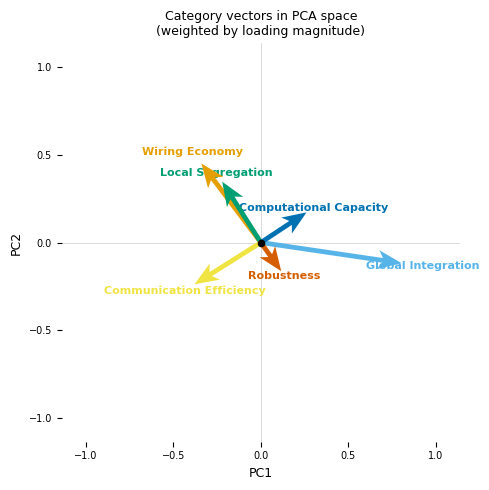

In [ ]:
# ── Category-level aggregate vectors ─────────────────────────────────────────
# loadings: DataFrame (n_vars × 2), already scaled by √eigenvalue

cat_vectors = {}
for cat, colour in CATEGORY_COLOURS.items():
    # Variables in this category that also have loadings
    cat_vars = [c for c in loadings.index
                if c in meta.index and meta.loc[c, "Category"] == cat]
    if not cat_vars:
        continue

    cat_loads = loadings.loc[cat_vars]  # shape: (n_cat_vars, 2)

    # Weight each variable by its total loading magnitude (L2 norm across PC1+PC2)
    weights = np.sqrt(cat_loads["PC1"]**2 + cat_loads["PC2"]**2)
    # weights = weights / weights.sum()  # normalise to sum=1

    # # Print the values of cat_loads["PC1"] and cat_loads["PC2"] for debugging (check if <0..)
    # print(f"Category: {cat}")
    # print("PC1 loadings:")
    # print(cat_loads["PC1"])
    # print("PC2 loadings:")
    # print(cat_loads["PC2"])
    
    # Weighted sum → one (PC1, PC2) vector per category
    vx = cat_loads["PC1"].mean() # sum() # (cat_loads["PC1"] * weights).sum()
    vy = cat_loads["PC2"].mean() # sum() # (cat_loads["PC2"] * weights).sum()
    cat_vectors[cat] = (vx, vy)
    
    # plt.scatter(cat_loads["PC1"], cat_loads["PC2"], color=colour, s=20)
    # plt.title(f"{cat} variables in PCA space")
    # plt.xlabel("PC1")
    # plt.ylabel("PC2")
    # plt.axhline(0, color="grey", lw=0.5, alpha=0.4)
    # plt.axvline(0, color="grey", lw=0.5, alpha=0.4)
    # plt.tight_layout()
    # plt.show()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
ax.scatter([0], [0], color="black", s=20, zorder=6)

for cat, (vx, vy) in cat_vectors.items():
    colour = CATEGORY_COLOURS[cat]
    ax.quiver(
        0, 0, vx, vy,
        angles="xy", scale_units="xy", scale=1,
        color=colour, width=0.012,
        headwidth=4, headlength=5, headaxislength=4,
        zorder=5,
    )
    nudge = 1.15
    ax.text(vx * nudge, vy * nudge, cat,
            fontsize=8, ha="center", va="center",
            color=colour, fontweight="bold")

# Symmetric axis limits
max_val = max(np.sqrt(vx**2 + vy**2) for vx, vy in cat_vectors.values()) * 1.4
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)
ax.set_aspect("equal")
ax.set_xlabel("PC1", fontsize=9)
ax.set_ylabel("PC2", fontsize=9)
ax.set_title("Category vectors in PCA space\n(weighted by loading magnitude)", fontsize=9)

# Remove frame, keep ticks
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(labelsize=7)

plt.tight_layout()

plt.savefig(output_folder / f"{dataset_name}_pca_category_vectors.pdf")
print(output_folder / f"{dataset_name}_pca_category_vectors.pdf")
plt.show()

In [ ]:
# ── Robustness components vector addition ─────────────────────────────────────
# Find the exact category name for robustness
target_cat = next((cat for cat in CATEGORY_COLOURS.keys() if "robustness" in cat.lower()), None)

if target_cat:
    colour = CATEGORY_COLOURS[target_cat]
    
    # Variables in this category that also have loadings
    cat_vars = [c for c in loadings.index
                if c in meta.index and meta.loc[c, "Category"] == target_cat]
    
    if cat_vars:
        cat_loads = loadings.loc[cat_vars]
        
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
        ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
        ax.scatter([0], [0], color="black", s=20, zorder=6)
        
        current_x, current_y = 0, 0
        
        for var_name, row in cat_loads.iterrows():
            vx = row["PC1"]
            vy = row["PC2"]
            
            # Draw the individual variable vector
            ax.quiver(
                current_x, current_y, vx, vy,
                angles="xy", scale_units="xy", scale=1,
                color=colour, width=0.008, alpha=0.6,
                headwidth=4, headlength=5, headaxislength=4,
                zorder=4,
            )
            
            # Label with friendly property name if available, else var_name
            nice_name = PROPERTY_NAMES.get(var_name, var_name) if "PROPERTY_NAMES" in globals() else var_name
            
            # Place label slightly offset from the midpoint of the arrow
            mid_x = current_x + vx / 2
            mid_y = current_y + vy / 2
            
            # Small heuristic for label offset to avoid overlapping the line
            offset_x = 0.05 * np.sign(vx) if vx != 0 else 0.05
            offset_y = 0.05 * np.sign(vy) if vy != 0 else 0.05
            
            ax.text(mid_x + offset_x, mid_y + offset_y, nice_name,
                    fontsize=8, ha="center", va="center",
                    color=colour, alpha=0.9,
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.5))
            
            current_x += vx
            current_y += vy
            
        # Draw the final sum vector
        ax.quiver(
            0, 0, current_x, current_y,
            angles="xy", scale_units="xy", scale=1,
            color="black", width=0.012,
            headwidth=4, headlength=5, headaxislength=4,
            zorder=5,
        )
        
        nudge_x = 0.05 * np.sign(current_x) if current_x != 0 else 0.05
        nudge_y = 0.05 * np.sign(current_y) if current_y != 0 else 0.05
        ax.text(current_x + nudge_x, current_y + nudge_y, f"Total {target_cat}",
                fontsize=10, ha="center", va="center",
                color="black", fontweight="bold")
                
        # Calculate axis limits
        max_lim = 0.1
        cx, cy = 0, 0
        all_x, all_y = [0], [0]
        for _, row in cat_loads.iterrows():
            cx += row["PC1"]
            cy += row["PC2"]
            all_x.append(cx)
            all_y.append(cy)
            
        max_x = max(max(all_x), abs(min(all_x))) * 1.3
        max_y = max(max(all_y), abs(min(all_y))) * 1.3
        max_lim = max(max_x, max_y, 0.1)

        ax.set_xlim(-max_lim, max_lim)
        ax.set_ylim(-max_lim, max_lim)
        ax.set_aspect("equal")
        ax.set_xlabel("PC1", fontsize=9)
        ax.set_ylabel("PC2", fontsize=9)
        ax.set_title(f"Composition of '{target_cat}' vector in PCA space", fontsize=11)
        
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.tick_params(labelsize=8)
        
        plt.tight_layout()
        plt.show()
else:
    print("Could not find a category matching 'robustness'")


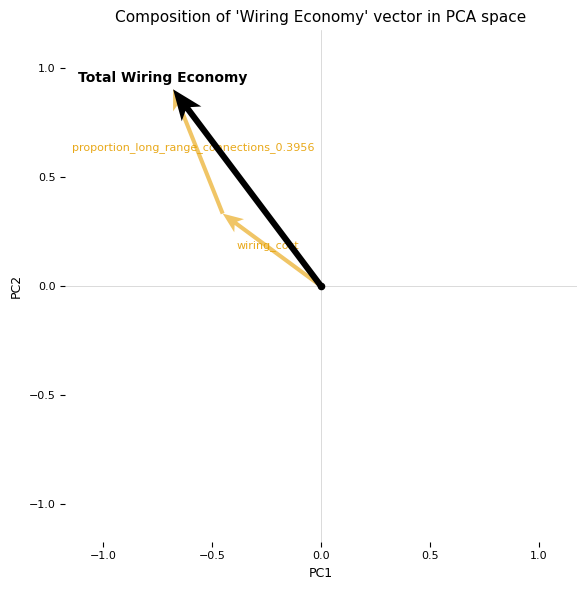

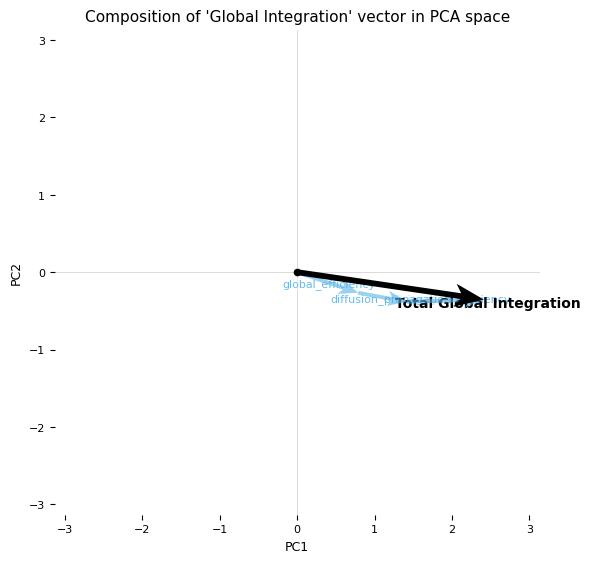

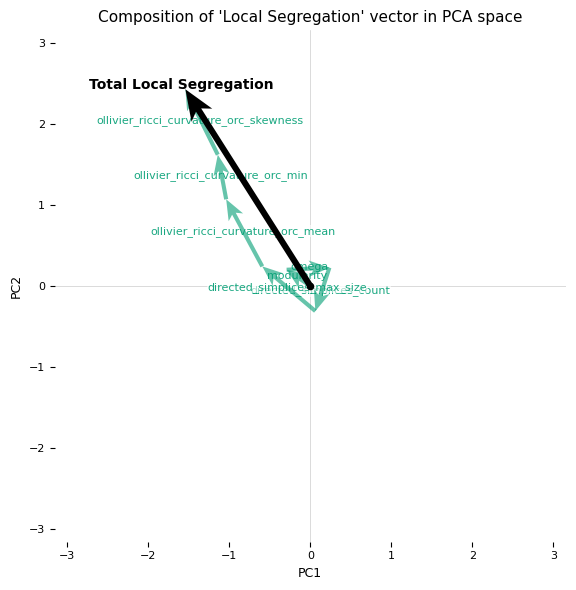

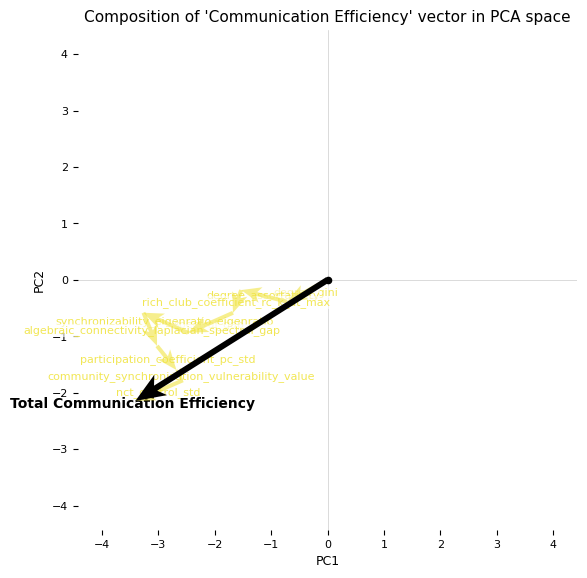

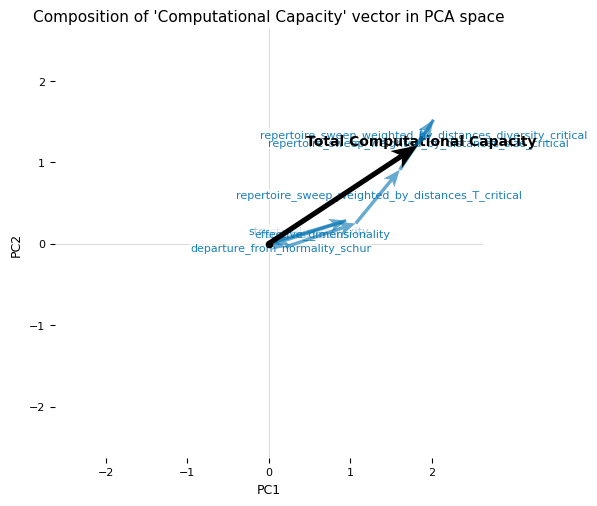

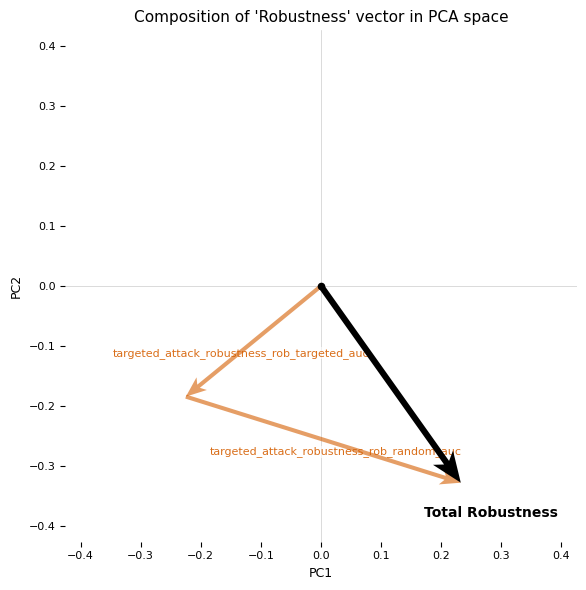

In [ ]:
# ── Per-category vector composition (chain addition) ─────────────────────────

for target_cat in CATEGORY_COLOURS.keys(): 

    if target_cat:
        colour = CATEGORY_COLOURS[target_cat]
        
        # Variables in this category that also have loadings
        cat_vars = [c for c in loadings.index
                    if c in meta.index and meta.loc[c, "Category"] == target_cat]
        
        if cat_vars:
            cat_loads = loadings.loc[cat_vars]
            
            fig, ax = plt.subplots(figsize=(6, 6))
            ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
            ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
            ax.scatter([0], [0], color="black", s=20, zorder=6)
            
            current_x, current_y = 0, 0
            
            for var_name, row in cat_loads.iterrows():
                vx = row["PC1"]
                vy = row["PC2"]
                
                # Draw the individual variable vector
                ax.quiver(
                    current_x, current_y, vx, vy,
                    angles="xy", scale_units="xy", scale=1,
                    color=colour, width=0.008, alpha=0.6,
                    headwidth=4, headlength=5, headaxislength=4,
                    zorder=4,
                )
                
                # Label with friendly property name if available, else var_name
                nice_name = SELECTED_PROPERTIES_NAMES.get(var_name, var_name)
                
                # Place label slightly offset from the midpoint of the arrow
                mid_x = current_x + vx / 2
                mid_y = current_y + vy / 2
                
                # Small heuristic for label offset to avoid overlapping the line
                offset_x = 0.02 * np.sign(vx) if vx != 0 else 0.02
                offset_y = 0.02 * np.sign(vy) if vy != 0 else 0.02
                
                ax.text(mid_x + offset_x, mid_y + offset_y, nice_name,
                        fontsize=8, ha="center", va="center",
                        color=colour, alpha=0.9,
                        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.5))
                
                current_x += vx
                current_y += vy
                
            # Draw the final sum vector
            ax.quiver(
                0, 0, current_x, current_y,
                angles="xy", scale_units="xy", scale=1,
                color="black", width=0.012,
                headwidth=4, headlength=5, headaxislength=4,
                zorder=5,
            )
            
            nudge_x = 0.05 * np.sign(current_x) if current_x != 0 else 0.05
            nudge_y = 0.05 * np.sign(current_y) if current_y != 0 else 0.05
            ax.text(current_x + nudge_x, current_y + nudge_y, f"Total {target_cat}",
                    fontsize=10, ha="center", va="center",
                    color="black", fontweight="bold")
                    
            # Calculate axis limits
            max_lim = 0.1
            cx, cy = 0, 0
            all_x, all_y = [0], [0]
            for _, row in cat_loads.iterrows():
                cx += row["PC1"]
                cy += row["PC2"]
                all_x.append(cx)
                all_y.append(cy)
                
            max_x = max(max(all_x), abs(min(all_x))) * 1.3
            max_y = max(max(all_y), abs(min(all_y))) * 1.3
            max_lim = max(max_x, max_y, 0.1)

            ax.set_xlim(-max_lim, max_lim)
            ax.set_ylim(-max_lim, max_lim)
            ax.set_aspect("equal")
            ax.set_xlabel("PC1", fontsize=9)
            ax.set_ylabel("PC2", fontsize=9)
            ax.set_title(f"Composition of '{target_cat}' vector in PCA space", fontsize=11)
            
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.tick_params(labelsize=8)
            
            plt.tight_layout()
            plt.show()
    else:
        print("Could not find a category matching 'robustness'")


# OLD

In [ ]:
stop here 

In [ ]:
import plotly.express as px
import pandas as pd

plot_df = pd.DataFrame({
    'PC1': sel_pca_result[:, 0],
    'PC2': sel_pca_result[:, 1],
    'PC3': sel_pca_result[:, 2],
    'age': huge_df["age"].values
})

fig = px.scatter_3d(
    plot_df, x='PC1', y='PC2', z='PC3',
    color='age',
    color_continuous_scale='hot',
    opacity=0.6,
    size_max=10,
    title='3D PCA colored by age (only datasets with age info)'
)
fig.update_traces(marker=dict(size=3))
fig.show()

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Fit UMAP on all data, then visualize age-labeled subset
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

# Fit on the full dataset (or just age subset — your choice, see note below)
age_mask = huge_df["age"].notna()
embedding = reducer.fit_transform(sel_pca_result)  # use PCA result as input

# Plot only age-labeled points
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    # embedding[:, 0],
    # embedding[:, 1],
    embedding[age_mask, 0],
    embedding[age_mask, 1],
    c=huge_df_age["age"],
    cmap="hot",
    s=10,
    alpha=0.6
)
plt.colorbar(sc, label="Age")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP colored by age")
plt.tight_layout()
plt.show()

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# Fit UMAP on all data, then visualize age-labeled subset
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)

# Fit on the full dataset (or just age subset — your choice, see note below)
embedding = reducer.fit_transform(sel_pca_result)  # use PCA result as input

# Plot only age-labeled points
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=huge_df_age["age"],
    cmap="hot",
    s=10,
    alpha=0.6
)
plt.colorbar(sc, label="Age")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("UMAP colored by age")
plt.tight_layout()
plt.show()

In [ ]:
# PHATE is actually purpose-built for continuous gradients
import phate
phate_op = phate.PHATE(n_components=2, random_state=42)
embedding_phate = phate_op.fit_transform(sel_pca_result[age_mask])

In [ ]:
plt.scatter(embedding_phate[:, 0], embedding_phate[:, 1], c=huge_df_age["age"], cmap="hot", s=10, alpha=0.6)

In [ ]:
age_mask

In [ ]:
# Which datasets are in that isolated cluster?
from sklearn.cluster import DBSCAN

clusters = DBSCAN(eps=0.5, min_samples=5).fit_predict(embedding)
# print(huge_df_age[age_mask].groupby(clusters)["dataset"].value_counts())  # or species/source column

In [ ]:
clusters

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full view
# Right: zoomed to main cluster
main = (embedding[:, 0] > -2) & (embedding[:, 1] > 10)  # adjust to your blob

for ax, mask in zip(axes, [age_mask, age_mask & main]):
    sc = ax.scatter(embedding[mask, 0], embedding[mask, 1],
                    c=huge_df_age["age"][mask],  # adjust indexing
                    cmap="plasma",   # better perceptual uniformity than "hot"
                    s=15, alpha=0.7,
                    vmin=np.percentile(huge_df_age["age"], 5),   # clip outliers
                    vmax=np.percentile(huge_df_age["age"], 95))
    plt.colorbar(sc, ax=ax, label="Age")

axes[0].set_title("Full UMAP")
axes[1].set_title("Main cluster zoomed")
plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

age_bins = pd.cut(huge_df_age["age"], bins=[0, 30, 50, 70, 100], 
                  labels=["<30", "30-50", "50-70", ">70"])

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
for ax, (label, grp) in zip(axes, huge_df_age.assign(bin=age_bins).groupby("bin")):
    idx = grp.index  # make sure this aligns with embedding rows
    sns.kdeplot(x=embedding[idx, 0], y=embedding[idx, 1], ax=ax, fill=True)
    ax.set_title(f"Age {label} (n={len(grp)})")
plt.tight_layout()

In [ ]:
from sklearn.metrics import pairwise_distances
from scipy.stats import f_oneway
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.utils import shuffle


X = pca_result[huge_df["age"].notna()][:, :2]  # PC1 + PC2 only
labels = sel_df_label[huge_df["age"].notna()]["dataset"].values

# # ── Extract the relevant PCA coordinates + labels ─────────────────────────────

# mami_mask  = (sel_df_label["dataset"] == "suarez_MaMI_dataset").values
# tax_mask   = df_mami[taxonomy].isin(GROUPS_TO_INCLUDE).values
# combined   = mami_mask.copy()
# combined[mami_mask] = tax_mask          # both conditions

# X      = sel_pca_result[combined, :2]   # PC1 + PC2 only
# labels = df_mami[tax_mask][taxonomy].values

# # ── Test 1: PERMANOVA (permutation-based MANOVA on distances) ─────────────────
# # "Are the groups more separated than random chance?"

# from sklearn.utils import shuffle

def permanova(X, labels, n_permutations=999):
    def f_stat(X, labels):
        groups  = [X[labels == g] for g in np.unique(labels)]
        grand_m = X.mean(axis=0)
        ss_between = sum(len(g) * ((g.mean(0) - grand_m)**2).sum() for g in groups)
        ss_within  = sum(((g - g.mean(0))**2).sum() for g in groups)
        k, n = len(groups), len(X)
        return (ss_between / (k-1)) / (ss_within / (n-k))

    observed = f_stat(X, labels)
    null_dist = [f_stat(X, shuffle(labels)) for _ in range(n_permutations)]
    p = (np.sum(np.array(null_dist) >= observed) + 1) / (n_permutations + 1)
    return observed, p

f_obs, p_perm = permanova(X, labels)
print(f"PERMANOVA  →  F = {f_obs:.3f},  p = {p_perm:.4f}")

# ── Test 2: Per-axis ANOVA ─────────────────────────────────────────────────────
# "Does any single PC axis separate the groups?"

groups_pc1 = [X[labels == g, 0] for g in np.unique(labels)]
groups_pc2 = [X[labels == g, 1] for g in np.unique(labels)]
f1, p1 = f_oneway(*groups_pc1)
f2, p2 = f_oneway(*groups_pc2)
print(f"ANOVA PC1  →  F = {f1:.3f},  p = {p1:.4f}")
print(f"ANOVA PC2  →  F = {f2:.3f},  p = {p2:.4f}")

# ── Test 3: LDA cross-validated accuracy ──────────────────────────────────────
# "Can we predict group membership better than chance?"

from sklearn.model_selection import cross_val_score
lda      = LinearDiscriminantAnalysis()
cv_score = cross_val_score(lda, X, labels, cv=5, scoring="accuracy").mean()
chance   = 1 / len(np.unique(labels))
print(f"LDA 5-fold CV accuracy = {cv_score:.3f}  (chance = {chance:.3f})")

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np

age_mask = huge_df["age"].notna()
X = huge_df[age_mask].drop(columns=["dataset", "age"]) #  sel_pca_result[age_mask]  # using PCA result as input (50 components recommended)
ages = huge_df_age["age"].values

# ── 1. t-SNE ──────────────────────────────────────────────────────────────────
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, # ages,
                    cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

plt.suptitle("t-SNE colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 2. Kernel PCA ─────────────────────────────────────────────────────────────
# Try rbf (non-linear) vs linear (should match regular PCA) vs poly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, ["rbf", "poly", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    emb = kpca.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Kernel PCA ({kernel})")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.suptitle("Kernel PCA colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Quantify: can Kernel PCA components predict age? ───────────────────────
# This is the key advantage of KernelPCA over UMAP/tSNE — you CAN regress on it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}
for kernel in ["linear", "rbf", "poly", "cosine"]:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X)
    cv_r2 = cross_val_score(LinearRegression(), X_kpca, ages, cv=5, scoring="r2")
    results[kernel] = (cv_r2.mean(), cv_r2.std())
    print(f"Kernel={kernel:8s} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

In [ ]:
age_mask = huge_df["age"] != -1
age_mask

In [ ]:
# 3D plot of KPCA (cosine) colored by age
from mpl_toolkits.mplot3d import Axes3D
kpca = KernelPCA(n_components=3, kernel="cosine", random_state=42)
X_kpca = kpca.fit_transform(X)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

age_mask = huge_df["age"] != -1

scatter = ax.scatter(X_kpca[age_mask][:, 0], 
                     X_kpca[age_mask][:, 1], 
                     X_kpca[age_mask][:, 2],
                     c=ages, 
                     cmap="plasma",
                     s=20, alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("KPC1")
ax.set_ylabel("KPC2")
ax.set_zlabel("KPC3")
ax.set_title("Kernel PCA (cosine) colored by age")
plt.tight_layout()
plt.show()

In [ ]:
# 3D plot of KPCA (poly) colored by age
from mpl_toolkits.mplot3d import Axes3D
kpca = KernelPCA(n_components=3, kernel="poly", random_state=42)
X_kpca = kpca.fit_transform(X)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

age_mask = huge_df["age"] != -1

scatter = ax.scatter(X_kpca[age_mask][:, 0], 
                     X_kpca[age_mask][:, 1], 
                     X_kpca[age_mask][:, 2],
                     c=ages, 
                     cmap="plasma",
                     s=20, alpha=0.6)
fig.colorbar(scatter, label="Age")
ax.set_xlabel("KPC1")
ax.set_ylabel("KPC2")
ax.set_zlabel("KPC3")
ax.set_title("Kernel PCA (cosine) colored by age")
plt.tight_layout()
plt.show()

In [ ]:
# Color your existing UMAP/t-SNE by dataset instead of age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: colored by dataset
sc1 = axes[0].scatter(embedding[age_mask, 0], embedding[age_mask, 1],
                       c=pd.factorize(huge_df_age[age_mask]["dataset"])[0],
                       cmap="tab20", s=10, alpha=0.6)
axes[0].set_title("Colored by dataset")

# Right: colored by age
sc2 = axes[1].scatter(embedding[age_mask, 0], 
                      embedding[age_mask, 1],
                       c=ages, # [age_mask], 
                       cmap="plasma", s=10, alpha=0.6)
axes[1].set_title("Colored by age")

plt.tight_layout()
plt.show()

In [ ]:
huge_df.keys()

In [ ]:
plt.scatter(embedding[:,0], 
            embedding[:,1], 
            c=huge_df["age"].values,
            s=1, 
            alpha=0.5,
            )

In [ ]:
plt.scatter(embedding[:,0], 
            embedding[:,1], 
            c=huge_df["age"].values,
            s=3, 
            alpha=0.5,
            cmap="hot",
            )

plt.xlim(-2, 2)
plt.ylim(11, 14)

In [ ]:
colors_dataset = [COLOR_SCHEME[d] for d in huge_df["dataset"]]
colors_dataset = []

plt.scatter(embedding[:,0], 
            embedding[:,1], 
            c=colors_dataset,
            s=1, 
            alpha=0.5,
            )

# Add legend for datasets
unique_datasets = huge_df["dataset"].unique()
color_map = plt.cm.get_cmap("tab20", len(unique_datasets))
dataset_colors = {ds: color_map(i) for i, ds in enumerate(unique_datasets)}
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=ds,
                              markerfacecolor=dataset_colors[ds], markersize=10)
                    for ds in unique_datasets],
           title="Dataset", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP colored by age and dataset")

In [ ]:
# plot each dataset separately in a grid of subplots
unique_datasets = huge_df["dataset"].unique()
n = len(unique_datasets)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 5*rows), sharex=True, sharey=True)

for ax, dataset in zip(axes.flatten(), unique_datasets):
    mask = huge_df["dataset"] == dataset
    # convert to boolean array
    mask = mask.values.astype(bool)

    ax.scatter(embedding[mask, 0], 
               embedding[mask, 1], 
               c=COLOR_SCHEME[dataset], 
               s=4, #1
               alpha=0.5)
    
    ax.set_title(dataset)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(14, 5))

for i, dataset in enumerate(huge_df_age[age_mask]["dataset"].unique()): # Left: colored by dataset
    that_dataset_mask = (huge_df_age[age_mask]["dataset"] == dataset)
    sc1 = axs[i].scatter(embedding[that_dataset_mask, 0], 
                         embedding[that_dataset_mask, 1],
                        c=i, # pd.factorize(huge_df_age[that_dataset_mask][age_mask]["dataset"])[0],
                        cmap="tab20", s=10, alpha=0.6)
    axs[i].set_title("Colored by dataset")

In [ ]:
# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(huge_df.drop("dataset", "age")) # _properties)

pca = PCA(n_components=10) # 10)
pca_result = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(x=pca_result[:,0], 
            y=pca_result[:,1], 
            s=2, 
            alpha=0.4, 
            c=huge_df['color_dataset'], 
            # label=huge_df['dataset']
        )
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.plot(range(0, len(explained_variance)), np.cumsum(explained_variance), marker="o", color="red",
        label="Cumulative")
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np

# age_mask = huge_df["age"].notna()
X = huge_df.drop(columns=["dataset", "age"]) #  sel_pca_result[age_mask]  # using PCA result as input (50 components recommended)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ages = huge_df_age["age"].values
ages_or_gray = huge_df["age"].values  # use age where available, else gray
ages_or_gray[huge_df["age"].isna()] = -1  # set missing ages to -1 for gray color
# ── 1. t-SNE ──────────────────────────────────────────────────────────────────
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages_or_gray, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages_or_gray, 5),
                    vmax=np.percentile(ages_or_gray, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

plt.suptitle("t-SNE colored by age", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    # tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    # emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages_or_gray, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages_or_gray, 5),
                    vmax=np.percentile(ages_or_gray, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_xlim(-30, 80)
    ax.set_ylim(-90, -50)
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

In [ ]:


# ── 2. Kernel PCA ─────────────────────────────────────────────────────────────
# Try rbf (non-linear) vs linear (should match regular PCA) vs poly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, ["rbf", "poly", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    emb = kpca.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Kernel PCA ({kernel})")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.suptitle("Kernel PCA colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Quantify: can Kernel PCA components predict age? ───────────────────────
# This is the key advantage of KernelPCA over UMAP/tSNE — you CAN regress on it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}
for kernel in ["linear", "rbf", "poly", "cosine"]:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X)
    cv_r2 = cross_val_score(LinearRegression(), X_kpca, ages, cv=5, scoring="r2")
    results[kernel] = (cv_r2.mean(), cv_r2.std())
    print(f"Kernel={kernel:8s} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt
import numpy as np

# age_mask = huge_df["age"].notna()
X = sel_pca_result # [age_mask]  # using PCA result as input (50 components recommended)
ages = huge_df_age["age"].values

# ── 1. t-SNE ──────────────────────────────────────────────────────────────────
# Try multiple perplexity values — this is the key hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, [15, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42) # , n_iter=1000)
    emb = tsne.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"t-SNE (perplexity={perp})")
    ax.set_xlabel("tSNE1")
    ax.set_ylabel("tSNE2")

plt.suptitle("t-SNE colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 2. Kernel PCA ─────────────────────────────────────────────────────────────
# Try rbf (non-linear) vs linear (should match regular PCA) vs poly
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kernel in zip(axes, ["rbf", "poly", "cosine"]):
    kpca = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    emb = kpca.fit_transform(X)
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=ages, cmap="plasma", s=10, alpha=0.6,
                    vmin=np.percentile(ages, 5),
                    vmax=np.percentile(ages, 95))
    plt.colorbar(sc, ax=ax, label="Age")
    ax.set_title(f"Kernel PCA ({kernel})")
    ax.set_xlabel("KPC1")
    ax.set_ylabel("KPC2")

plt.suptitle("Kernel PCA colored by age", y=1.02)
plt.tight_layout()
plt.show()

# ── 3. Quantify: can Kernel PCA components predict age? ───────────────────────
# This is the key advantage of KernelPCA over UMAP/tSNE — you CAN regress on it
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

results = {}
for kernel in ["linear", "rbf", "poly", "cosine"]:
    kpca = KernelPCA(n_components=10, kernel=kernel, random_state=42)
    X_kpca = kpca.fit_transform(X)
    cv_r2 = cross_val_score(LinearRegression(), X_kpca, ages, cv=5, scoring="r2")
    results[kernel] = (cv_r2.mean(), cv_r2.std())
    print(f"Kernel={kernel:8s} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

In [ ]:
import cebra
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
import pandas as pd

# ── Setup ──────────────────────────────────────────────────────────────────────
age_mask = huge_df["age"] != -1  #  huge_df["age"].notna() &only rows with age and dataset info
X = sel_pca_result[age_mask].astype(np.float32)        # input: PCA features
ages = huge_df_age[age_mask]["age"].values.astype(np.float32)    # continuous label
groups = huge_df_age[age_mask]["dataset"].values              # for dataset-aware CV

# ── 1. CEBRA with age as the conditioning variable (supervised) ────────────────
cebra_model = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=1e-3,
    temperature=1.0,
    output_dimension=3,          # 3D embedding
    max_iterations=5000,
    verbose=True,
    device="cpu"                 # change to "cuda" if available
)

# Fit conditioned on age — this is the key difference from PCA/UMAP/t-SNE
cebra_model.fit(X, ages)
embedding_age = cebra_model.transform(X)

# ── 2. CEBRA without label (unsupervised) for comparison ──────────────────────
cebra_model_unsup = cebra.CEBRA(
    model_architecture="offset10-model",
    batch_size=512,
    learning_rate=1e-3,
    output_dimension=3,
    max_iterations=5000,
    verbose=True,
    device="cpu"
)
cebra_model_unsup.fit(X)
embedding_unsup = cebra_model_unsup.transform(X)

# ── 3. Visualize: supervised vs unsupervised, colored by age AND dataset ───────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

dataset_ids = pd.factorize(groups)[0]

plots = [
    (embedding_age,  ages,        "plasma", "CEBRA (age-supervised) — colored by age"),
    (embedding_age,  dataset_ids, "tab20",  "CEBRA (age-supervised) — colored by dataset"),
    (embedding_unsup, ages,       "plasma", "CEBRA (unsupervised) — colored by age"),
    (embedding_unsup, dataset_ids,"tab20",  "CEBRA (unsupervised) — colored by dataset"),
]

for ax, (emb, color, cmap, title) in zip(axes.flat, plots):
    sc = ax.scatter(emb[:, 0], emb[:, 1],
                    c=color, cmap=cmap, s=10, alpha=0.6)
    plt.colorbar(sc, ax=ax, label="Age" if cmap == "plasma" else "Dataset")
    ax.set_title(title)
    ax.set_xlabel("CEBRA1")
    ax.set_ylabel("CEBRA2")

plt.suptitle("CEBRA embeddings: supervised vs unsupervised", y=1.01, fontsize=14)
plt.tight_layout()
plt.show